# Cross-store and cross-product seasonality

This notebook searches for products whose weekly demand moves together:

1. **Across stores** — do stores show the same normalized weekly shape?
2. **Across years** — does that shape repeat in 2023, 2024, and 2025?
3. **Across products** — which products form seasonal families?
4. **Across source classes** — are recent FCM and Pseudo products correlated?
5. **No clear connections** — which products agree neither across stores nor with other products?

Demand is aggregated weekly and normalized within each store/year, so large and small stores can be compared by shape. The stable-season analysis uses only the complete years 2023–2025. FCM is analysed separately because its history starts in April 2025.

In [1]:
import warnings

import duckdb
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_GLOB = "../../data/interim/transactions_dst_daily_no_tail_no_outliers/*.parquet"
FULL_YEARS = (2023, 2024, 2025)
REFERENCE_ARTICLE_ID = 317123
MIN_STORES = 10

SOURCE_COLORS = {"Other": "#38686A", "Pseudo": "#E3A83B", "FCM": "#D45D45"}
GROUP_COLORS = {
    "Barbecue / summer": "#E76F51",
    "Christmas roasts": "#6D597A",
    "Winter cured meats": "#457B9D",
    "Easter lamb": "#2A9D8F",
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight"})

con = duckdb.connect()
con.execute("PRAGMA threads=4")


## 1. Data coverage by source class

,source_class,rows,stores,products,first_date,last_date
0,FCM,399041,105,27,2025-04-17,2026-07-10
1,Other,10001422,105,766,2023-01-02,2026-07-10
2,Pseudo,11767762,106,341,2023-01-02,2026-07-10


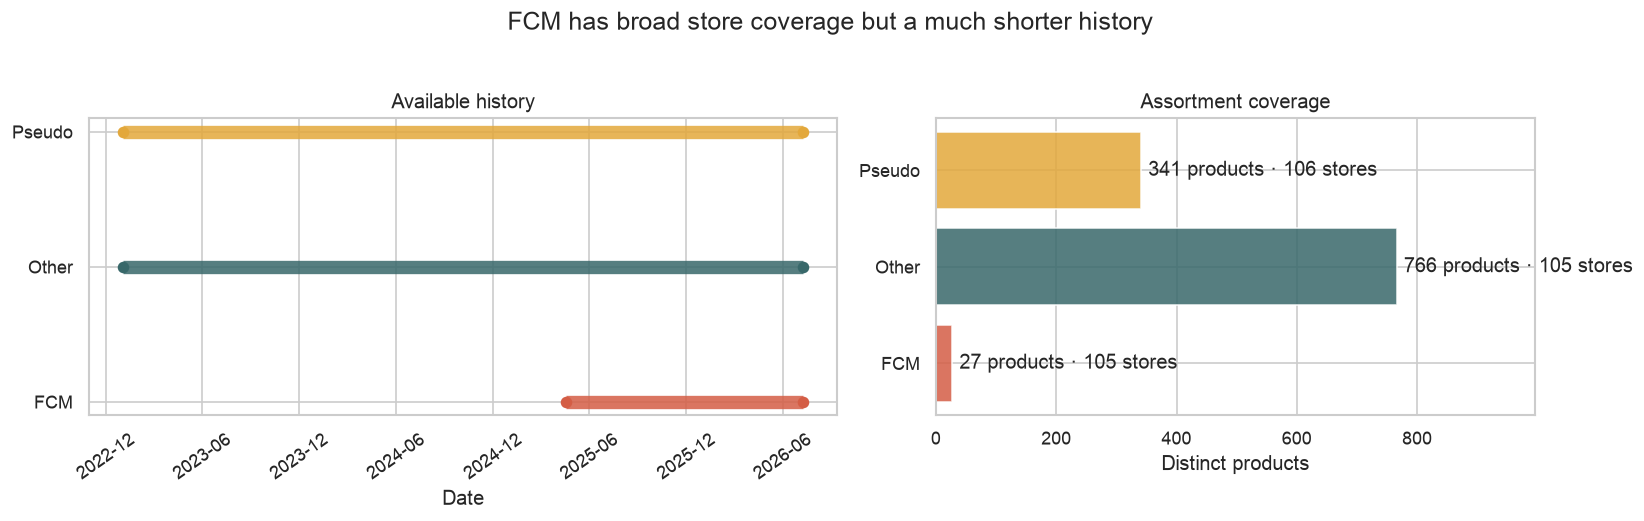

In [2]:
coverage = con.execute(f"""
    SELECT
        CASE
            WHEN is_fcm THEN 'FCM'
            WHEN is_pseudo THEN 'Pseudo'
            ELSE 'Other'
        END AS source_class,
        count(*) AS rows,
        count(DISTINCT MARKT_ID) AS stores,
        count(DISTINCT ARTIKEL_ID) AS products,
        min(DATE::DATE) AS first_date,
        max(DATE::DATE) AS last_date
    FROM read_parquet('{DATA_GLOB}')
    GROUP BY 1
    ORDER BY 1
""").fetchdf()

display(coverage)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1.25, 1]})

for y, row in coverage.reset_index(drop=True).iterrows():
    color = SOURCE_COLORS[row.source_class]
    axes[0].hlines(y, row.first_date, row.last_date, color=color, linewidth=8, alpha=0.85)
    axes[0].scatter([row.first_date, row.last_date], [y, y], color=color, s=35, zorder=3)
axes[0].set_yticks(range(len(coverage)), coverage.source_class)
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[0].tick_params(axis="x", rotation=35)
axes[0].set_title("Available history")
axes[0].set_xlabel("Date")

colors = [SOURCE_COLORS[x] for x in coverage.source_class]
bars = axes[1].barh(coverage.source_class, coverage.products, color=colors, alpha=0.85)
for bar, products, stores in zip(bars, coverage.products, coverage.stores):
    axes[1].text(
        bar.get_width() + 12,
        bar.get_y() + bar.get_height() / 2,
        f"{products} products · {stores} stores",
        va="center",
    )
axes[1].set_xlim(0, coverage.products.max() * 1.3)
axes[1].set_title("Assortment coverage")
axes[1].set_xlabel("Distinct products")

fig.suptitle("FCM has broad store coverage but a much shorter history", fontsize=15, y=1.03)
fig.tight_layout()
plt.show()


## 2. Stable weekly seasonality (2023–2025)

A product/store pair is retained when it occurs in all three complete years, has at least 40 observed weeks per year, and positive annual demand. Missing weeks inside an eligible series are filled with zero. Each store-year is divided by its own mean weekly demand.

The main metrics are:

- **Store agreement:** median correlation of each store's normalized weekly curve with the product's cross-store median curve.
- **Year repeatability:** median correlation between the 2023, 2024, and 2025 product profiles.
- **Seasonal CV:** variation of the 52-week mean profile; larger values indicate a more concentrated season.

In [3]:
con.execute(f"""
CREATE OR REPLACE TEMP TABLE weekly_full AS
SELECT
    ARTIKEL_ID AS article_id,
    any_value(ARTIKEL_BEZ) AS product_name,
    CASE
        WHEN bool_or(is_fcm) THEN 'FCM'
        WHEN bool_or(is_pseudo) THEN 'Pseudo'
        ELSE 'Other'
    END AS source_class,
    MARKT_ID AS store_id,
    year(DATE::DATE) AS sales_year,
    week(DATE::DATE) AS sales_week,
    sum(ABVERKAUFTE_MENGE_KG) AS demand_kg
FROM read_parquet('{DATA_GLOB}')
WHERE year(DATE::DATE) BETWEEN 2023 AND 2025
GROUP BY ARTIKEL_ID, MARKT_ID, year(DATE::DATE), week(DATE::DATE)
""")

con.execute("""
CREATE OR REPLACE TEMP TABLE eligible_product_stores AS
WITH yearly_coverage AS (
    SELECT
        article_id,
        store_id,
        sales_year,
        count(*) AS observed_weeks,
        sum(demand_kg) AS annual_demand
    FROM weekly_full
    GROUP BY article_id, store_id, sales_year
),
three_year_coverage AS (
    SELECT
        article_id,
        store_id,
        count(*) AS covered_years,
        min(observed_weeks) AS min_observed_weeks,
        min(annual_demand) AS min_annual_demand
    FROM yearly_coverage
    GROUP BY article_id, store_id
)
SELECT article_id, store_id
FROM three_year_coverage
WHERE covered_years = 3
  AND min_observed_weeks >= 40
  AND min_annual_demand > 0
""")

con.execute("""
CREATE OR REPLACE TEMP TABLE normalized_store_year_week AS
WITH grid AS (
    SELECT e.article_id, e.store_id, y.sales_year, w.sales_week
    FROM eligible_product_stores e
    CROSS JOIN range(2023, 2026) y(sales_year)
    CROSS JOIN range(1, 53) w(sales_week)
),
filled AS (
    SELECT
        g.article_id,
        g.store_id,
        g.sales_year,
        g.sales_week,
        coalesce(w.demand_kg, 0.0) AS demand_kg
    FROM grid g
    LEFT JOIN weekly_full w USING (article_id, store_id, sales_year, sales_week)
),
with_mean AS (
    SELECT
        *,
        avg(demand_kg) OVER (
            PARTITION BY article_id, store_id, sales_year
        ) AS mean_weekly_demand
    FROM filled
)
SELECT
    article_id,
    store_id,
    sales_year,
    sales_week,
    demand_kg / nullif(mean_weekly_demand, 0) AS normalized_demand
FROM with_mean
""")

con.execute("""
CREATE OR REPLACE TEMP TABLE product_year_profile AS
SELECT
    article_id,
    sales_year,
    sales_week,
    median(normalized_demand) AS profile_value
FROM normalized_store_year_week
GROUP BY article_id, sales_year, sales_week
""")

con.execute("""
CREATE OR REPLACE TEMP TABLE product_profile AS
SELECT article_id, sales_week, avg(profile_value) AS profile_value
FROM product_year_profile
GROUP BY article_id, sales_week
""")

metrics = con.execute("""
WITH store_correlations AS (
    SELECT
        n.article_id,
        n.store_id,
        n.sales_year,
        corr(n.normalized_demand, p.profile_value) AS store_correlation
    FROM normalized_store_year_week n
    JOIN product_year_profile p USING (article_id, sales_year, sales_week)
    GROUP BY n.article_id, n.store_id, n.sales_year
),
cross_store AS (
    SELECT
        article_id,
        median(store_correlation) AS median_store_correlation
    FROM store_correlations
    GROUP BY article_id
),
year_pairs AS (
    SELECT
        a.article_id,
        a.sales_year AS year_a,
        b.sales_year AS year_b,
        corr(a.profile_value, b.profile_value) AS year_correlation
    FROM product_year_profile a
    JOIN product_year_profile b
      ON a.article_id = b.article_id
     AND a.sales_week = b.sales_week
     AND a.sales_year < b.sales_year
    GROUP BY a.article_id, a.sales_year, b.sales_year
),
year_metrics AS (
    SELECT
        article_id,
        median(year_correlation) AS median_year_correlation,
        min(year_correlation) AS minimum_year_correlation
    FROM year_pairs
    GROUP BY article_id
),
profile_metrics AS (
    SELECT
        article_id,
        stddev_samp(profile_value) / nullif(avg(profile_value), 0) AS seasonal_cv,
        max(profile_value) / nullif(avg(profile_value), 0) AS peak_multiple,
        arg_max(sales_week, profile_value) AS peak_week
    FROM product_profile
    GROUP BY article_id
),
store_counts AS (
    SELECT article_id, count(*) AS eligible_stores
    FROM eligible_product_stores
    GROUP BY article_id
),
names AS (
    SELECT
        article_id,
        any_value(product_name) AS product_name,
        any_value(source_class) AS source_class
    FROM weekly_full
    GROUP BY article_id
)
SELECT
    n.*,
    s.eligible_stores,
    c.median_store_correlation,
    y.median_year_correlation,
    y.minimum_year_correlation,
    p.seasonal_cv,
    p.peak_multiple,
    p.peak_week,
    p.seasonal_cv
      * greatest(c.median_store_correlation, 0)
      * greatest(y.median_year_correlation, 0) AS seasonal_score
FROM names n
JOIN store_counts s USING (article_id)
JOIN cross_store c USING (article_id)
JOIN year_metrics y USING (article_id)
JOIN profile_metrics p USING (article_id)
ORDER BY seasonal_score DESC NULLS LAST
""").fetchdf()

analysis_metrics = metrics[metrics["eligible_stores"] >= MIN_STORES].copy()
print(f"Products with at least {MIN_STORES} eligible stores: {len(analysis_metrics):,}")
display(analysis_metrics[analysis_metrics.article_id == REFERENCE_ARTICLE_ID])


Products with at least 10 eligible stores: 295


,article_id,product_name,source_class,eligible_stores,median_store_correlation,median_year_correlation,minimum_year_correlation,seasonal_cv,peak_multiple,peak_week,seasonal_score
54,317123,"Nackensteak mariniert, vom Schwein",Pseudo,94,0.951077,0.518471,0.502232,0.781323,2.611935,20,0.385275


## 3. Seasonality landscape

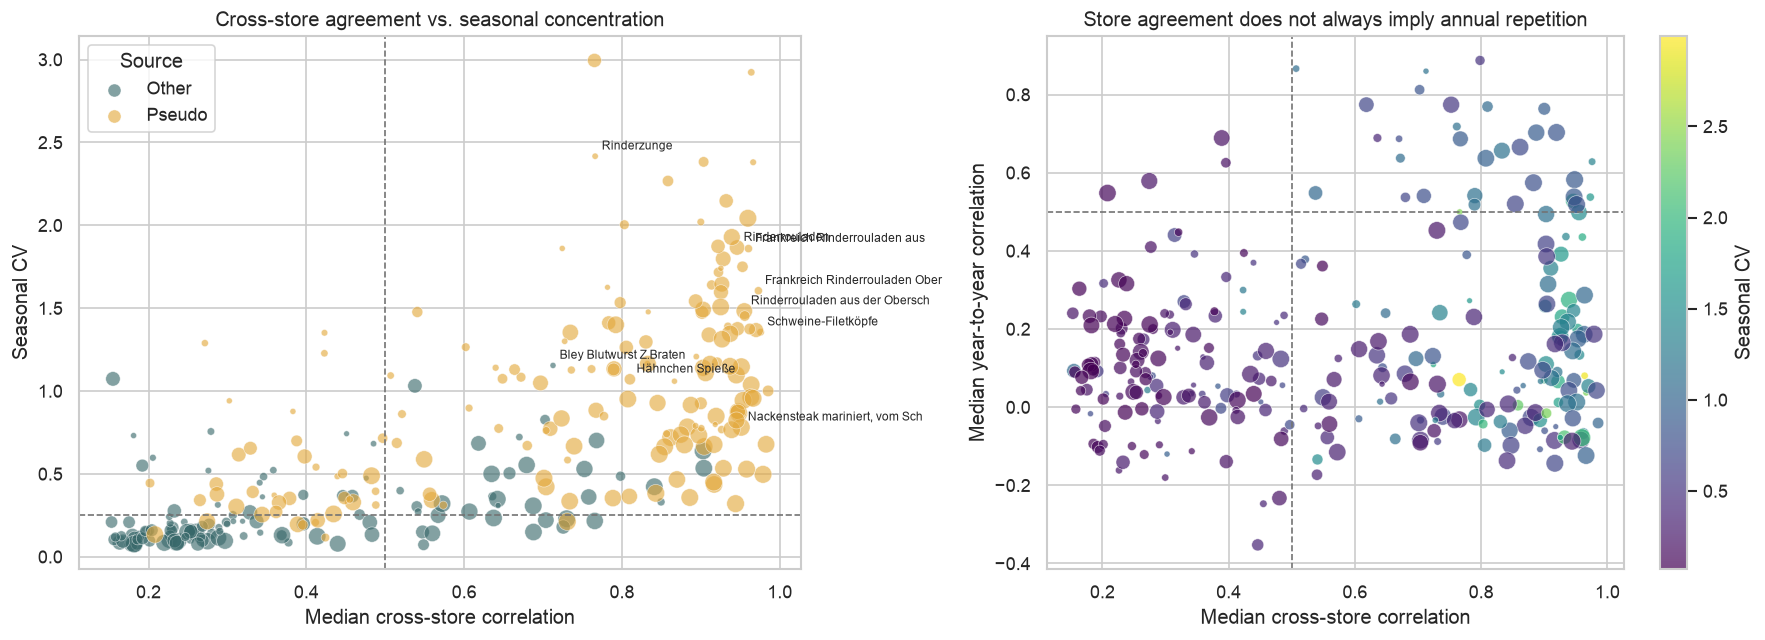

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for source_class, group in analysis_metrics.groupby("source_class"):
    axes[0].scatter(
        group.median_store_correlation,
        group.seasonal_cv,
        s=np.clip(group.eligible_stores, 10, 100) * 1.2,
        alpha=0.62,
        color=SOURCE_COLORS[source_class],
        label=source_class,
        edgecolor="white",
        linewidth=0.4,
    )

label_ids = set(
    analysis_metrics.nlargest(8, "seasonal_score").article_id.tolist()
    + [REFERENCE_ARTICLE_ID]
)
for row in analysis_metrics[analysis_metrics.article_id.isin(label_ids)].itertuples():
    axes[0].annotate(
        row.product_name[:30],
        (row.median_store_correlation, row.seasonal_cv),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=7,
    )

axes[0].axvline(0.5, color="0.45", linestyle="--", linewidth=1)
axes[0].axhline(0.25, color="0.45", linestyle="--", linewidth=1)
axes[0].set_xlabel("Median cross-store correlation")
axes[0].set_ylabel("Seasonal CV")
axes[0].set_title("Cross-store agreement vs. seasonal concentration")
axes[0].legend(title="Source")

scatter = axes[1].scatter(
    analysis_metrics.median_store_correlation,
    analysis_metrics.median_year_correlation,
    c=analysis_metrics.seasonal_cv,
    cmap="viridis",
    s=np.clip(analysis_metrics.eligible_stores, 10, 100) * 1.2,
    alpha=0.7,
    edgecolor="white",
    linewidth=0.4,
)
axes[1].axvline(0.5, color="0.45", linestyle="--", linewidth=1)
axes[1].axhline(0.5, color="0.45", linestyle="--", linewidth=1)
axes[1].set_xlabel("Median cross-store correlation")
axes[1].set_ylabel("Median year-to-year correlation")
axes[1].set_title("Store agreement does not always imply annual repetition")
fig.colorbar(scatter, ax=axes[1], label="Seasonal CV")

fig.tight_layout()
plt.show()


## 4. Nackensteak: synchronized across stores

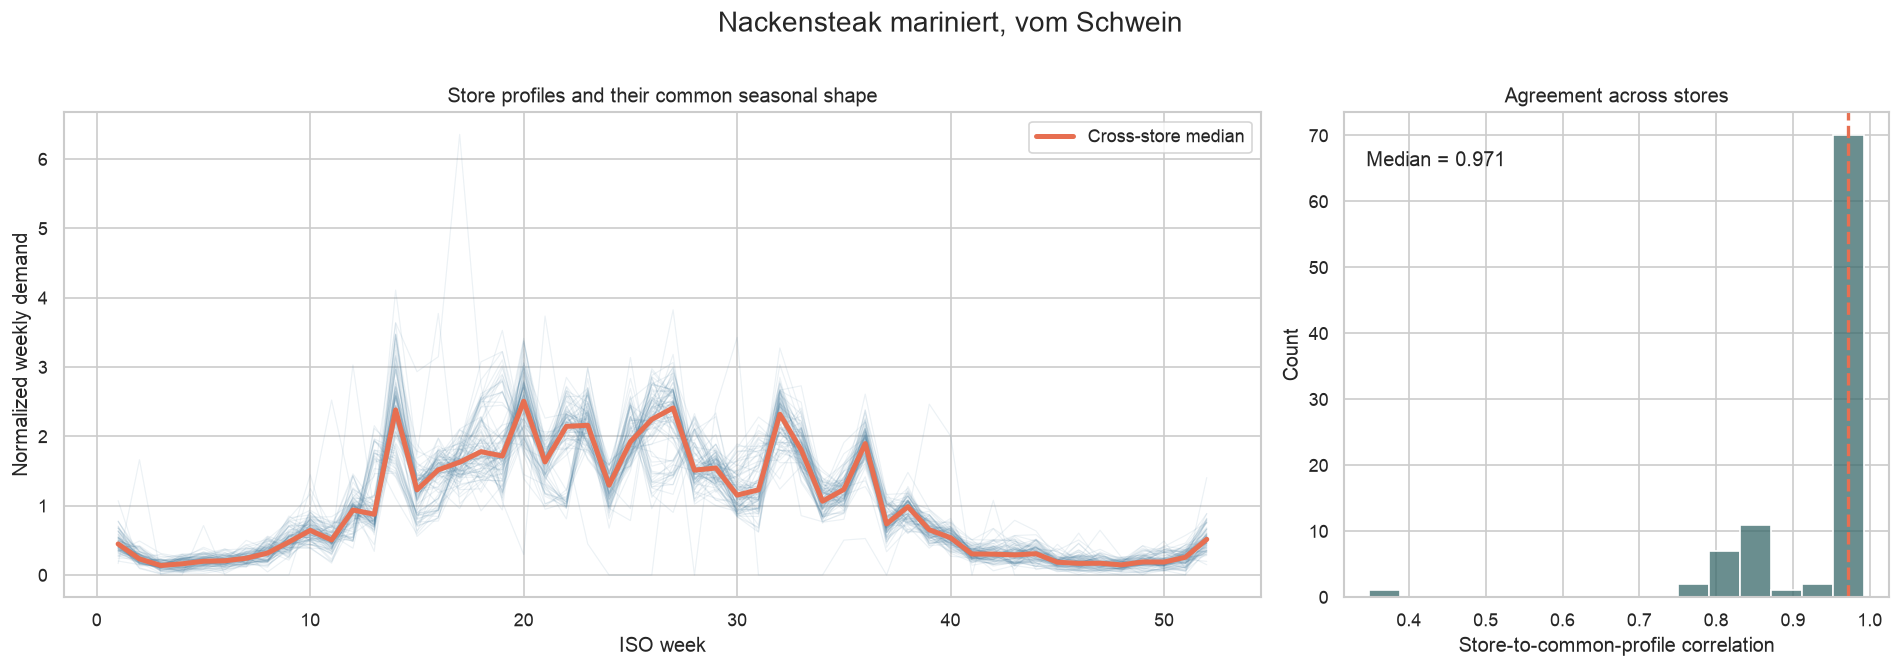

In [5]:
nacken_store_profiles = con.execute(f"""
    SELECT
        store_id,
        sales_week,
        avg(normalized_demand) AS normalized_demand
    FROM normalized_store_year_week
    WHERE article_id = {REFERENCE_ARTICLE_ID}
    GROUP BY store_id, sales_week
    ORDER BY store_id, sales_week
""").fetchdf()

nacken_matrix = nacken_store_profiles.pivot(
    index="store_id", columns="sales_week", values="normalized_demand"
)
nacken_reference = nacken_matrix.median(axis=0)
nacken_correlations = nacken_matrix.apply(lambda row: row.corr(nacken_reference), axis=1)
nacken_matrix = nacken_matrix.loc[nacken_correlations.sort_values(ascending=False).index]

fig, (ax_lines, ax_hist) = plt.subplots(
    1, 2, figsize=(16, 5.5), gridspec_kw={"width_ratios": [2.2, 1]}
)
for _, row in nacken_matrix.iterrows():
    ax_lines.plot(row.index, row.values, color="#457B9D", alpha=0.10, linewidth=0.7)
ax_lines.plot(
    nacken_reference.index,
    nacken_reference.values,
    color="#E76F51",
    linewidth=3,
    label="Cross-store median",
)
ax_lines.set_xlabel("ISO week")
ax_lines.set_ylabel("Normalized weekly demand")
ax_lines.set_title("Store profiles and their common seasonal shape")
ax_lines.legend()

sns.histplot(nacken_correlations, bins=16, color="#38686A", ax=ax_hist)
ax_hist.axvline(nacken_correlations.median(), color="#E76F51", linestyle="--", linewidth=2)
ax_hist.text(
    0.04,
    0.92,
    f"Median = {nacken_correlations.median():.3f}",
    transform=ax_hist.transAxes,
    va="top",
)
ax_hist.set_xlabel("Store-to-common-profile correlation")
ax_hist.set_title("Agreement across stores")

fig.suptitle("Nackensteak mariniert, vom Schwein", fontsize=17, y=1.01)
fig.tight_layout()
plt.show()


## 5. Seasonal product families

The following groups combine automated profile similarity with interpretable product families. Easter receives a separate event-aligned view because its calendar week changes from year to year.

In [6]:
PRODUCT_GROUPS = {
    "Barbecue / summer": [
        317123, 317204, 318149, 629118, 329560, 317164,
        748734, 317181, 317200, 627050, 317157, 317119,
    ],
    "Christmas roasts": [316708, 911705, 316791, 318159],
    "Winter cured meats": [1086334, 294582, 1086331, 901024],
    "Easter lamb": [317043, 317033, 317004],
}

group_lookup = {
    article_id: group_name
    for group_name, article_ids in PRODUCT_GROUPS.items()
    for article_id in article_ids
}
selected_ids = sorted(group_lookup)

group_profiles = con.execute(f"""
    SELECT p.article_id, p.sales_week, p.profile_value
    FROM product_profile p
    WHERE p.article_id IN ({','.join(map(str, selected_ids))})
    ORDER BY p.article_id, p.sales_week
""").fetchdf()

name_lookup = (
    metrics.set_index("article_id")["product_name"].to_dict()
)
group_profiles["product_name"] = group_profiles.article_id.map(name_lookup)
group_profiles["group"] = group_profiles.article_id.map(group_lookup)

group_summary = (
    metrics[metrics.article_id.isin(selected_ids)]
    .assign(group=lambda x: x.article_id.map(group_lookup))
    [[
        "group", "article_id", "product_name", "source_class", "eligible_stores",
        "median_store_correlation", "median_year_correlation", "peak_week",
    ]]
    .sort_values(["group", "median_store_correlation"], ascending=[True, False])
)
display(group_summary)


,group,article_id,product_name,source_class,eligible_stores,median_store_correlation,median_year_correlation,peak_week
54,Barbecue / summer,317123,"Nackensteak mariniert, vom Schwein",Pseudo,94,0.951077,0.518471,20
39,Barbecue / summer,317157,"Bauchscheiben gewürzt, vom Schwein",Pseudo,94,0.947982,0.582159,18
46,Barbecue / summer,317119,Schweinerückensteaks mariniert,Pseudo,93,0.947114,0.537968,18
31,Barbecue / summer,318149,"Grillröllchen Schweinelachs mit Käsefüllung, m...",Pseudo,93,0.919267,0.702950,19
24,Barbecue / summer,317204,"Grillies Kachelfleisch mariniert, vom Schwein",Pseudo,48,0.899904,0.763506,18
28,Barbecue / summer,317164,Grillschnecken Grobe Schweinebratwurst im Sait...,Pseudo,87,0.887228,0.702564,20
51,Barbecue / summer,629118,Hähnchen Minutensteak / -schnitzel gewürzt,Pseudo,91,0.861563,0.665470,20
23,Barbecue / summer,317200,Grillfackeln vom Schwein,Pseudo,83,0.832809,0.656405,19
19,Barbecue / summer,627050,Hähnchen Spieße,Pseudo,38,0.809976,0.769203,25
35,Barbecue / summer,748734,Spieße mit Bacon (Datteln od. Pflaume - Aprikose),Pseudo,91,0.807351,0.636918,20


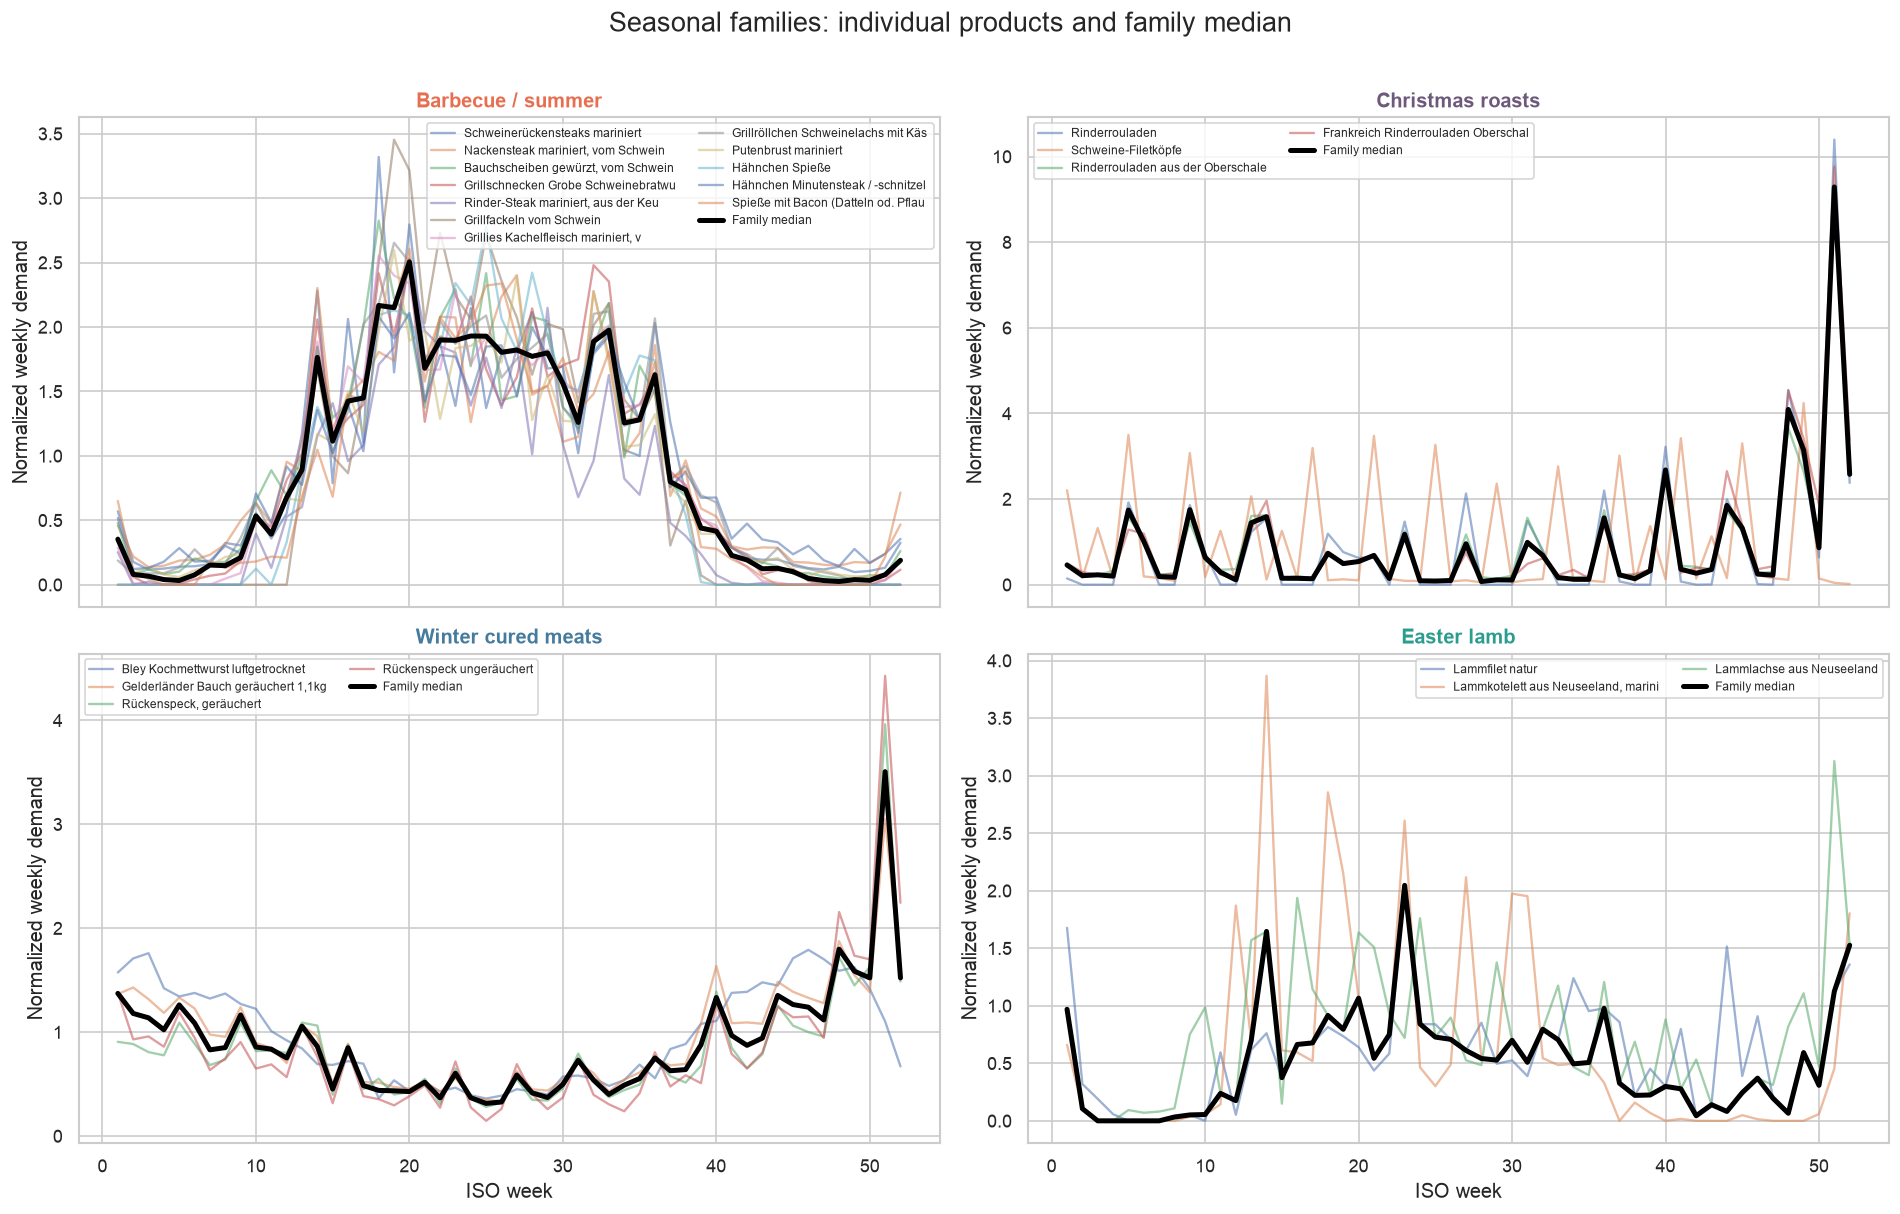

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

for ax, (group_name, article_ids) in zip(axes.flat, PRODUCT_GROUPS.items()):
    group_data = group_profiles[group_profiles.group == group_name]
    for article_id, product_data in group_data.groupby("article_id"):
        ax.plot(
            product_data.sales_week,
            product_data.profile_value,
            alpha=0.55,
            linewidth=1.4,
            label=name_lookup.get(article_id, str(article_id))[:35],
        )
    family_median = group_data.groupby("sales_week").profile_value.median()
    ax.plot(
        family_median.index,
        family_median.values,
        color="black",
        linewidth=3,
        label="Family median",
    )
    ax.set_title(group_name, color=GROUP_COLORS[group_name], fontweight="bold")
    ax.set_ylabel("Normalized weekly demand")
    ax.legend(fontsize=7, ncol=2)

for ax in axes[-1]:
    ax.set_xlabel("ISO week")
fig.suptitle("Seasonal families: individual products and family median", fontsize=16, y=1.01)
fig.tight_layout()
plt.show()


### Easter-aligned lamb demand

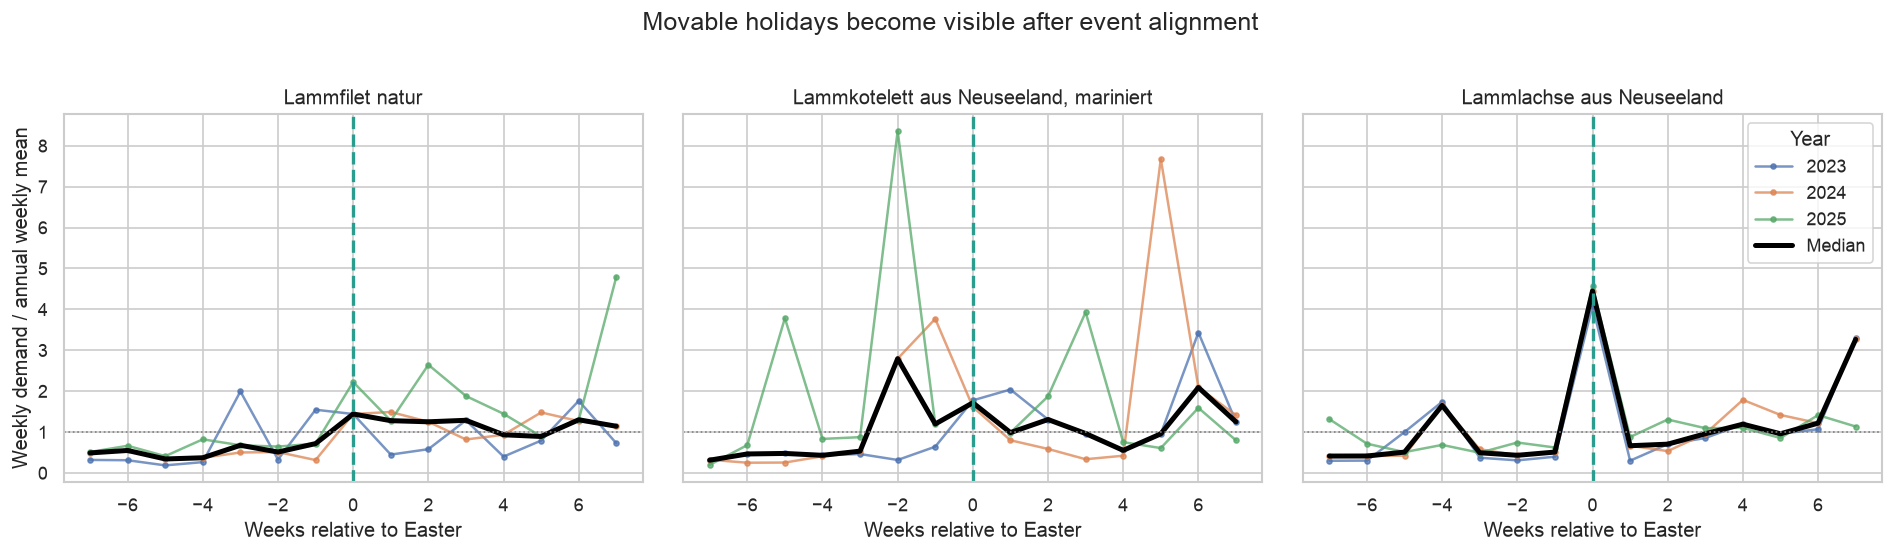

In [8]:
easter_aligned = con.execute(f"""
WITH easter(sales_year, easter_date) AS (
    VALUES
        (2023, DATE '2023-04-09'),
        (2024, DATE '2024-03-31'),
        (2025, DATE '2025-04-20')
),
weekly AS (
    SELECT
        ARTIKEL_ID AS article_id,
        any_value(ARTIKEL_BEZ) AS product_name,
        year(DATE::DATE) AS sales_year,
        date_trunc('week', DATE::DATE)::DATE AS week_date,
        sum(ABVERKAUFTE_MENGE_KG) AS demand_kg
    FROM read_parquet('{DATA_GLOB}')
    WHERE ARTIKEL_ID IN (317043, 317033, 317004)
      AND year(DATE::DATE) BETWEEN 2023 AND 2025
    GROUP BY ARTIKEL_ID, year(DATE::DATE), date_trunc('week', DATE::DATE)
),
normalized AS (
    SELECT
        *,
        demand_kg / nullif(avg(demand_kg) OVER (
            PARTITION BY article_id, sales_year
        ), 0) AS demand_vs_annual_week
    FROM weekly
)
SELECT
    n.*,
    date_diff(
        'week', date_trunc('week', e.easter_date), n.week_date
    ) AS weeks_from_easter
FROM normalized n
JOIN easter e USING (sales_year)
WHERE abs(date_diff(
    'week', date_trunc('week', e.easter_date), n.week_date
)) <= 7
ORDER BY article_id, sales_year, weeks_from_easter
""").fetchdf()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, (article_id, product_data) in zip(axes, easter_aligned.groupby("article_id")):
    for sales_year, year_data in product_data.groupby("sales_year"):
        ax.plot(
            year_data.weeks_from_easter,
            year_data.demand_vs_annual_week,
            marker="o",
            markersize=3,
            linewidth=1.5,
            alpha=0.75,
            label=str(sales_year),
        )
    median_profile = product_data.groupby("weeks_from_easter").demand_vs_annual_week.median()
    ax.plot(median_profile.index, median_profile.values, color="black", linewidth=3, label="Median")
    ax.axvline(0, color=GROUP_COLORS["Easter lamb"], linestyle="--", linewidth=2)
    ax.axhline(1, color="0.5", linestyle=":", linewidth=1)
    ax.set_title(product_data.product_name.iloc[0])
    ax.set_xlabel("Weeks relative to Easter")
axes[0].set_ylabel("Weekly demand / annual weekly mean")
axes[-1].legend(title="Year")
fig.suptitle("Movable holidays become visible after event alignment", fontsize=15, y=1.02)
fig.tight_layout()
plt.show()


## 6. Within-family and between-family connections

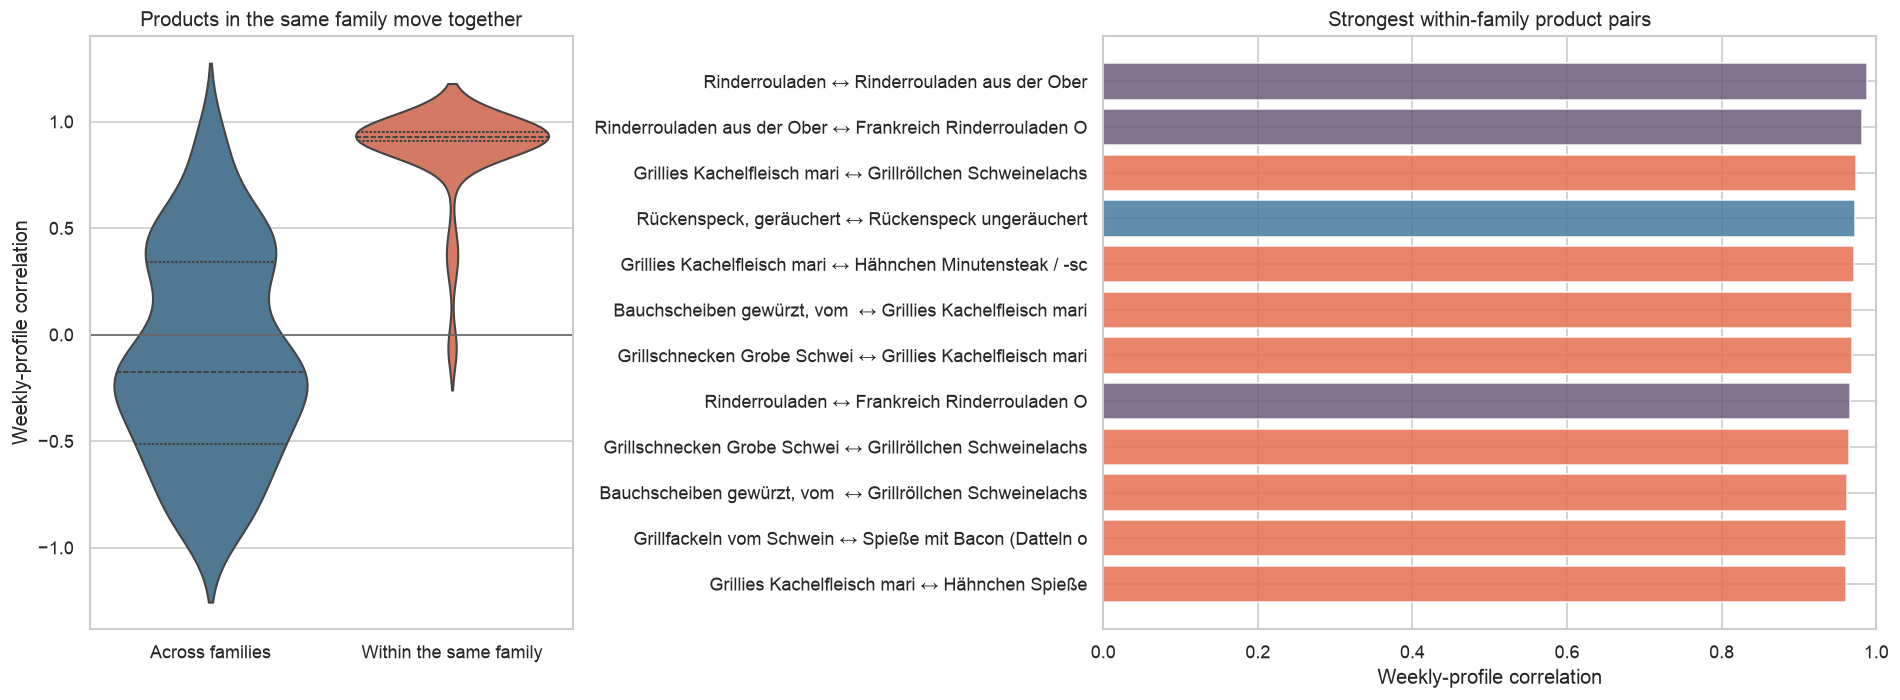

In [9]:
selected_profile_matrix = group_profiles.pivot(
    index="sales_week", columns="article_id", values="profile_value"
)
selected_product_corr = selected_profile_matrix.corr()

pair_rows = []
for position, article_a in enumerate(selected_product_corr.index):
    for article_b in selected_product_corr.columns[position + 1:]:
        group_a = group_lookup[article_a]
        group_b = group_lookup[article_b]
        pair_rows.append({
            "product_a": name_lookup.get(article_a, str(article_a)),
            "product_b": name_lookup.get(article_b, str(article_b)),
            "group_a": group_a,
            "group_b": group_b,
            "comparison": "Within the same family" if group_a == group_b else "Across families",
            "correlation": selected_product_corr.at[article_a, article_b],
        })
family_pairs = pd.DataFrame(pair_rows).dropna(subset=["correlation"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 1.6]})
sns.violinplot(
    data=family_pairs,
    x="comparison",
    y="correlation",
    hue="comparison",
    palette=["#457B9D", "#E76F51"],
    inner="quartile",
    legend=False,
    ax=axes[0],
)
axes[0].axhline(0, color="0.4", linewidth=1)
axes[0].set_xlabel("")
axes[0].set_ylabel("Weekly-profile correlation")
axes[0].set_title("Products in the same family move together")

strongest_within = (
    family_pairs[family_pairs.comparison == "Within the same family"]
    .nlargest(12, "correlation")
    .copy()
)
strongest_within["pair"] = (
    strongest_within.product_a.str.slice(0, 27)
    + " ↔ "
    + strongest_within.product_b.str.slice(0, 27)
)
strongest_within = strongest_within.sort_values("correlation")
axes[1].barh(
    strongest_within["pair"],
    strongest_within.correlation,
    color=[GROUP_COLORS[group] for group in strongest_within.group_a],
    alpha=0.85,
)
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("Weekly-profile correlation")
axes[1].set_title("Strongest within-family product pairs")

fig.tight_layout()
plt.show()


## 7. FCM and Pseudo correlations

FCM starts in April 2025, so this section uses absolute calendar weeks from April 2025 through July 2026. Correlation here means that two products rose and fell in the same weeks. It can reflect common promotions or rollout timing and is **not yet proof of annual seasonality**. At least 26 overlapping weeks are required for each displayed FCM–Pseudo pair.

In [10]:
con.execute(f"""
CREATE OR REPLACE TEMP TABLE recent_weekly AS
SELECT
    ARTIKEL_ID AS article_id,
    any_value(ARTIKEL_BEZ) AS product_name,
    CASE
        WHEN is_fcm THEN 'FCM'
        WHEN is_pseudo THEN 'Pseudo'
        ELSE 'Other'
    END AS source_class,
    MARKT_ID AS store_id,
    date_trunc('week', DATE::DATE)::DATE AS week_date,
    sum(ABVERKAUFTE_MENGE_KG) AS demand_kg
FROM read_parquet('{DATA_GLOB}')
WHERE DATE::DATE >= DATE '2025-04-14'
GROUP BY ARTIKEL_ID, source_class, MARKT_ID, date_trunc('week', DATE::DATE)
""")

con.execute("""
CREATE OR REPLACE TEMP TABLE recent_eligible AS
SELECT article_id, source_class, store_id
FROM recent_weekly
GROUP BY article_id, source_class, store_id
HAVING count(*) >= 12 AND sum(demand_kg) > 0
""")

con.execute("""
CREATE OR REPLACE TEMP TABLE recent_normalized AS
SELECT
    w.*,
    w.demand_kg / nullif(avg(w.demand_kg) OVER (
        PARTITION BY w.article_id, w.source_class, w.store_id
    ), 0) AS normalized_demand
FROM recent_weekly w
JOIN recent_eligible e USING (article_id, source_class, store_id)
""")

con.execute("""
CREATE OR REPLACE TEMP TABLE recent_product_profile AS
SELECT
    article_id,
    any_value(product_name) AS product_name,
    source_class,
    week_date,
    median(normalized_demand) AS profile_value,
    count(DISTINCT store_id) AS stores
FROM recent_normalized
GROUP BY article_id, source_class, week_date
""")

recent_info = con.execute("""
    SELECT
        article_id,
        any_value(product_name) AS product_name,
        source_class,
        max(stores) AS eligible_stores,
        count(*) AS profile_weeks,
        min(week_date) AS first_week,
        max(week_date) AS last_week
    FROM recent_product_profile
    GROUP BY article_id, source_class
""").fetchdf()

display(
    recent_info[recent_info.source_class == "FCM"]
    .sort_values(["profile_weeks", "eligible_stores"], ascending=False)
    .reset_index(drop=True)
)


,article_id,product_name,source_class,eligible_stores,profile_weeks,first_week,last_week
0,1382768,Fleischkäse ofengebacken,FCM,101,65,2025-04-14,2026-07-06
1,1382766,Fleischwurst mit Knoblauch,FCM,95,62,2025-05-05,2026-07-06
2,1382767,Fleischwurst ohne Knoblauch,FCM,95,62,2025-05-05,2026-07-06
3,1382863,Rostbratwurst (eigene Herstellung),FCM,26,62,2025-05-05,2026-07-06
4,1382764,Braunschweiger grobe Streichmettwurst,FCM,103,60,2025-05-19,2026-07-06
5,1382788,"Goldmarie Friesen Bratwurst, gebrüht",FCM,95,59,2025-05-26,2026-07-06
6,1376860,Pfefferbeißer,FCM,80,59,2025-05-26,2026-07-06
7,1382765,Braunschweiger feine Streichmettwurst,FCM,103,58,2025-06-02,2026-07-06
8,1382858,Goldmarie Krakauer,FCM,61,55,2025-06-23,2026-07-06
9,1382777,Goldmarie gekochte Schweinemettwurst,FCM,101,51,2025-07-21,2026-07-06


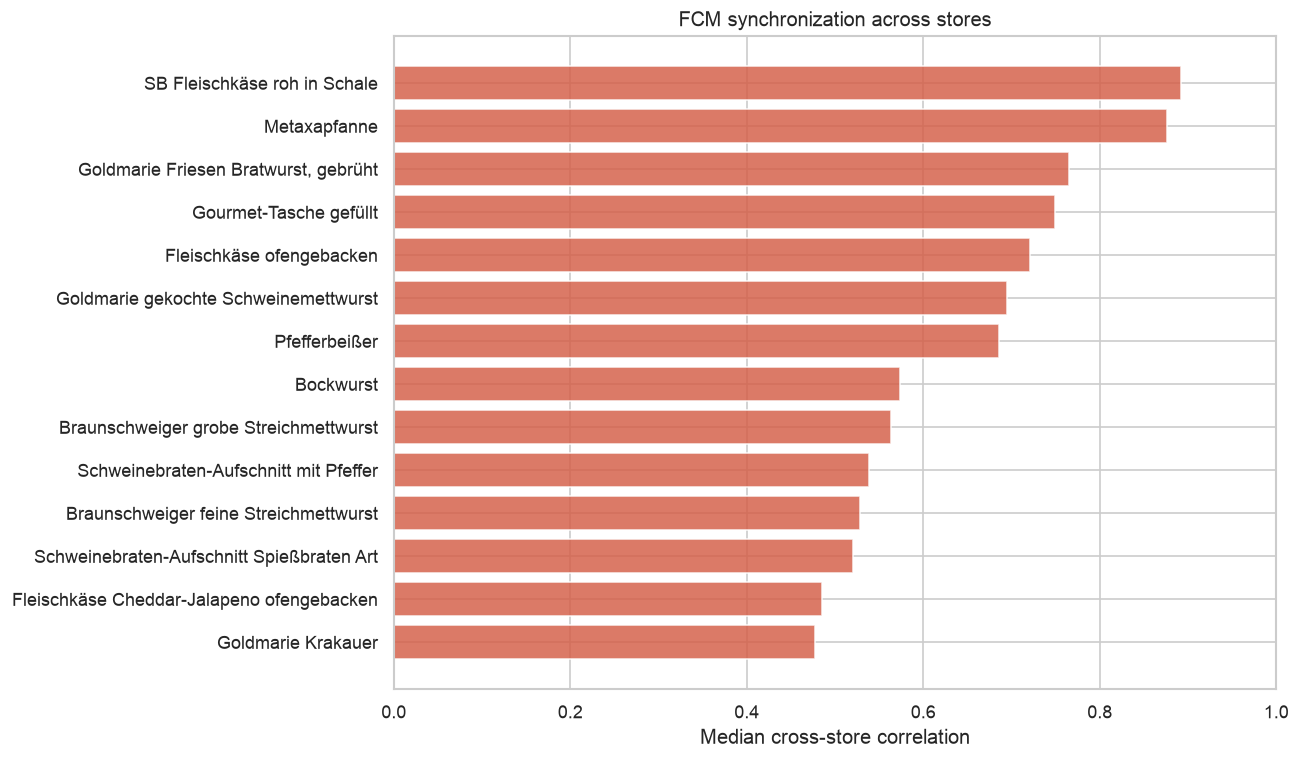

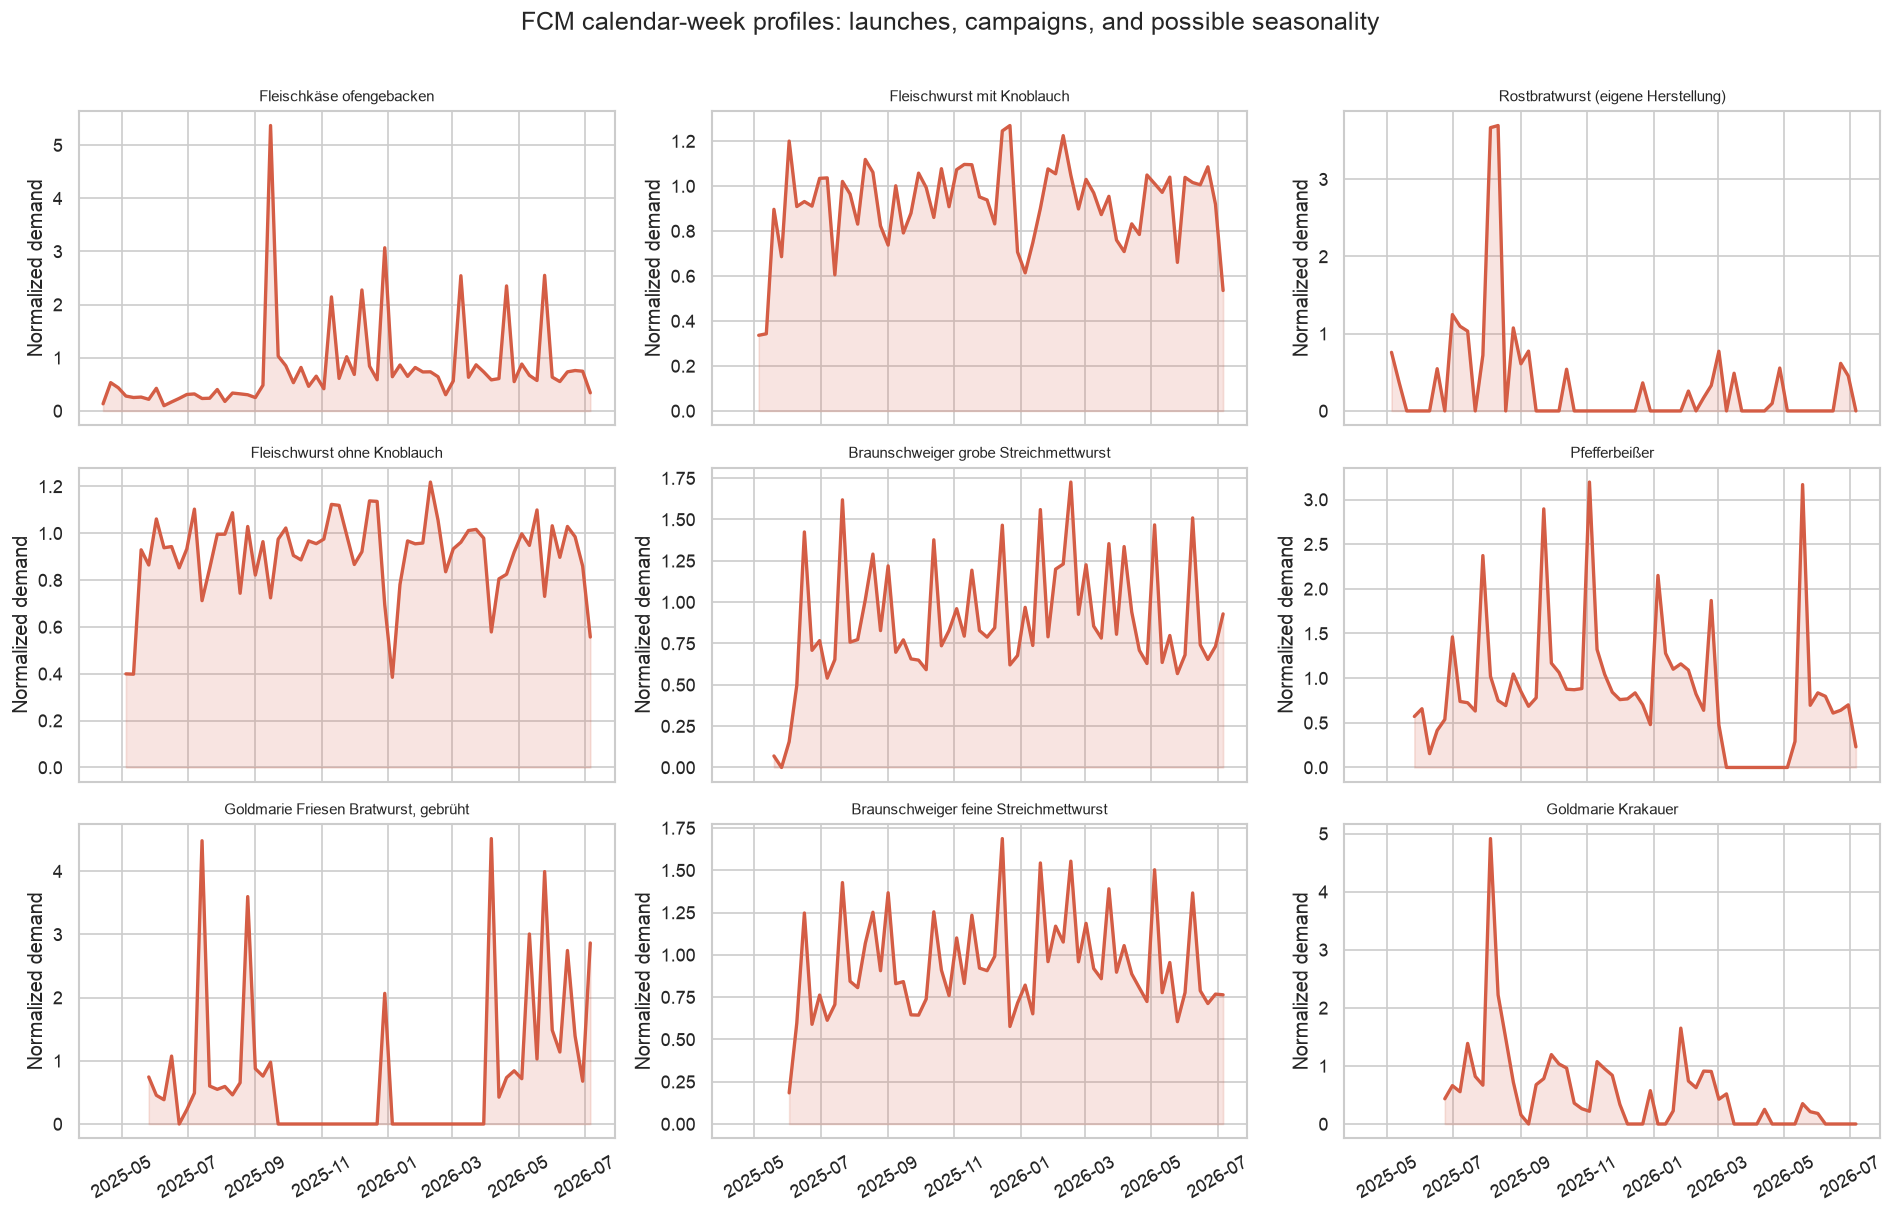

In [11]:
fcm_store_agreement = con.execute("""
WITH store_correlations AS (
    SELECT
        n.article_id,
        any_value(n.product_name) AS product_name,
        n.store_id,
        corr(n.normalized_demand, p.profile_value) AS store_correlation,
        count(*) AS compared_weeks
    FROM recent_normalized n
    JOIN recent_product_profile p
      USING (article_id, source_class, week_date)
    WHERE n.source_class = 'FCM'
    GROUP BY n.article_id, n.store_id
    HAVING count(*) >= 12
)
SELECT
    article_id,
    any_value(product_name) AS product_name,
    count(*) AS eligible_stores,
    median(compared_weeks) AS median_weeks,
    median(store_correlation) AS median_store_correlation
FROM store_correlations
GROUP BY article_id
HAVING count(*) >= 10
ORDER BY median_store_correlation DESC
""").fetchdf()

fcm_profiles = con.execute("""
    SELECT article_id, product_name, week_date, profile_value
    FROM recent_product_profile
    WHERE source_class = 'FCM'
""").fetchdf()

top_fcm = fcm_store_agreement.head(14).sort_values("median_store_correlation")
fig, ax = plt.subplots(figsize=(11, 6.5))
ax.barh(
    top_fcm.product_name,
    top_fcm.median_store_correlation,
    color=SOURCE_COLORS["FCM"],
    alpha=0.82,
)
ax.set_xlim(0, 1)
ax.set_xlabel("Median cross-store correlation")
ax.set_title("FCM synchronization across stores")
fig.tight_layout()
plt.show()

longest_fcm_ids = (
    recent_info.query("source_class == 'FCM' and eligible_stores >= 10")
    .nlargest(9, "profile_weeks")
    .article_id
    .tolist()
)
fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharex=True)
for ax, article_id in zip(axes.flat, longest_fcm_ids):
    product_data = fcm_profiles[fcm_profiles.article_id == article_id].sort_values("week_date")
    ax.plot(product_data.week_date, product_data.profile_value, color=SOURCE_COLORS["FCM"], linewidth=2)
    ax.fill_between(
        product_data.week_date,
        0,
        product_data.profile_value,
        color=SOURCE_COLORS["FCM"],
        alpha=0.16,
    )
    ax.set_title(product_data.product_name.iloc[0], fontsize=9)
    ax.tick_params(axis="x", rotation=30)
    ax.set_ylabel("Normalized demand")
for ax in axes.flat[len(longest_fcm_ids):]:
    ax.set_visible(False)
fig.suptitle("FCM calendar-week profiles: launches, campaigns, and possible seasonality", fontsize=15, y=1.01)
fig.tight_layout()
plt.show()


### Provisional FCM seasonal-family assignment

Each sufficiently observed FCM product is compared with the four stable 2023–2025 family profiles after mapping its calendar dates to ISO week. An assignment is **strong** when the best correlation is at least 0.60 and clearly exceeds the runner-up; it is **tentative** from 0.30 with a smaller but meaningful lead. Everything else remains unassigned. These labels describe profile similarity, not yet proven annual repetition.

,article_id,FCM product,assigned_group,confidence,best_matching_group,best_correlation,runner_up,runner_up_correlation,margin,compared_weeks
0,1413151,Fleischkäse Cheddar-Jalapeno ofengebacken,Christmas roasts,Tentative,Christmas roasts,0.547780,Winter cured meats,0.496948,0.050832,31
1,1382788,"Goldmarie Friesen Bratwurst, gebrüht",Barbecue / summer,Tentative,Barbecue / summer,0.528950,Easter lamb,0.243695,0.285255,52
2,1382863,Rostbratwurst (eigene Herstellung),Barbecue / summer,Tentative,Barbecue / summer,0.369643,Easter lamb,0.109898,0.259745,52
3,1382766,Fleischwurst mit Knoblauch,Unassigned,Unassigned,Christmas roasts,0.348990,Winter cured meats,0.345595,0.003395,52
4,1382767,Fleischwurst ohne Knoblauch,Unassigned,Unassigned,Christmas roasts,0.291617,Winter cured meats,0.274525,0.017092,52
5,1382765,Braunschweiger feine Streichmettwurst,Unassigned,Unassigned,Winter cured meats,0.245423,Christmas roasts,0.232549,0.012873,52
6,1376860,Pfefferbeißer,Unassigned,Unassigned,Winter cured meats,0.171222,Christmas roasts,0.062280,0.108942,52
7,1382764,Braunschweiger grobe Streichmettwurst,Unassigned,Unassigned,Winter cured meats,0.156912,Christmas roasts,0.092967,0.063945,52
8,1382768,Fleischkäse ofengebacken,Unassigned,Unassigned,Winter cured meats,0.151879,Christmas roasts,-0.042928,0.194807,52
9,1406063,SB Fleischkäse roh in Schale,Unassigned,Unassigned,Winter cured meats,0.082502,Christmas roasts,-0.012355,0.094857,43


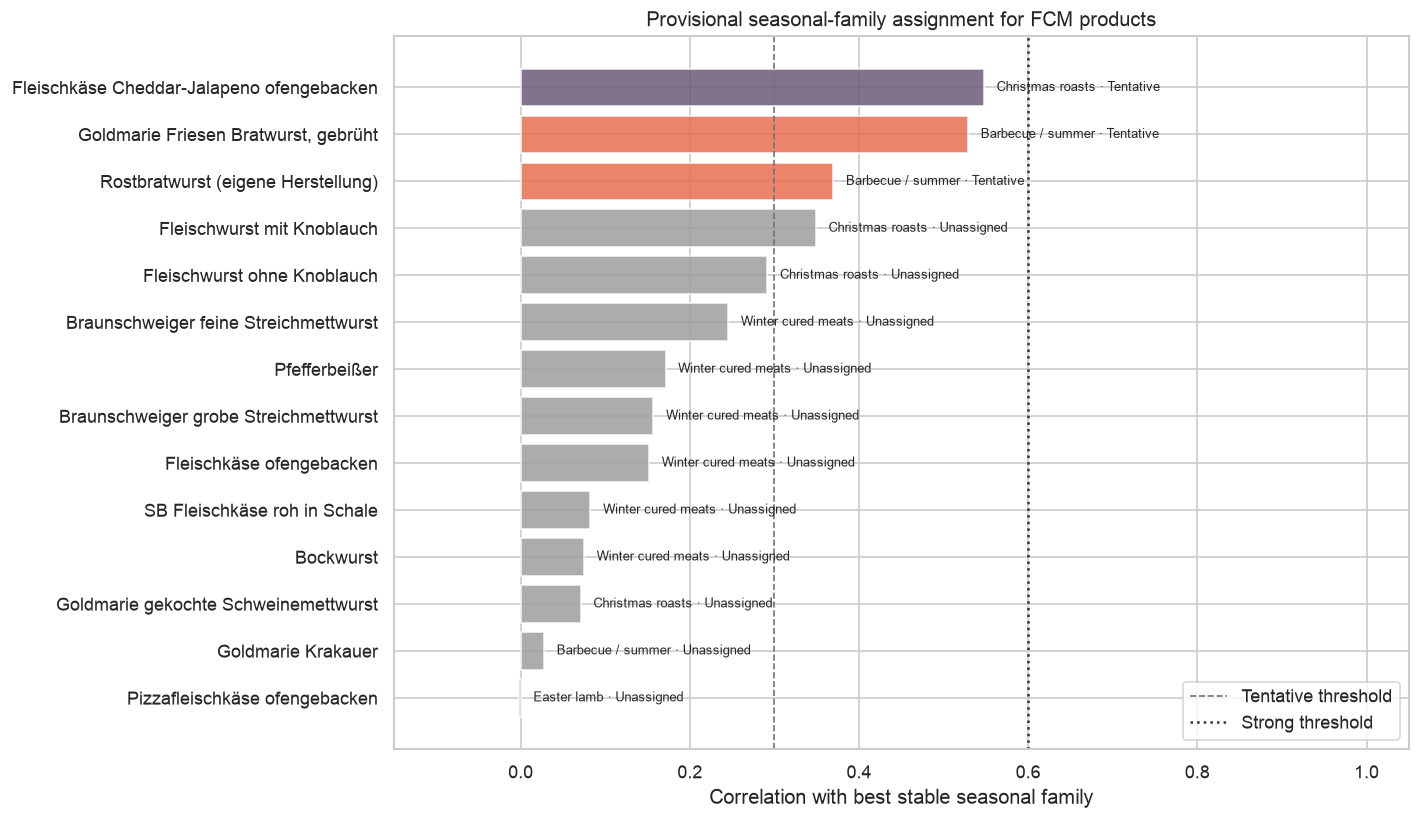

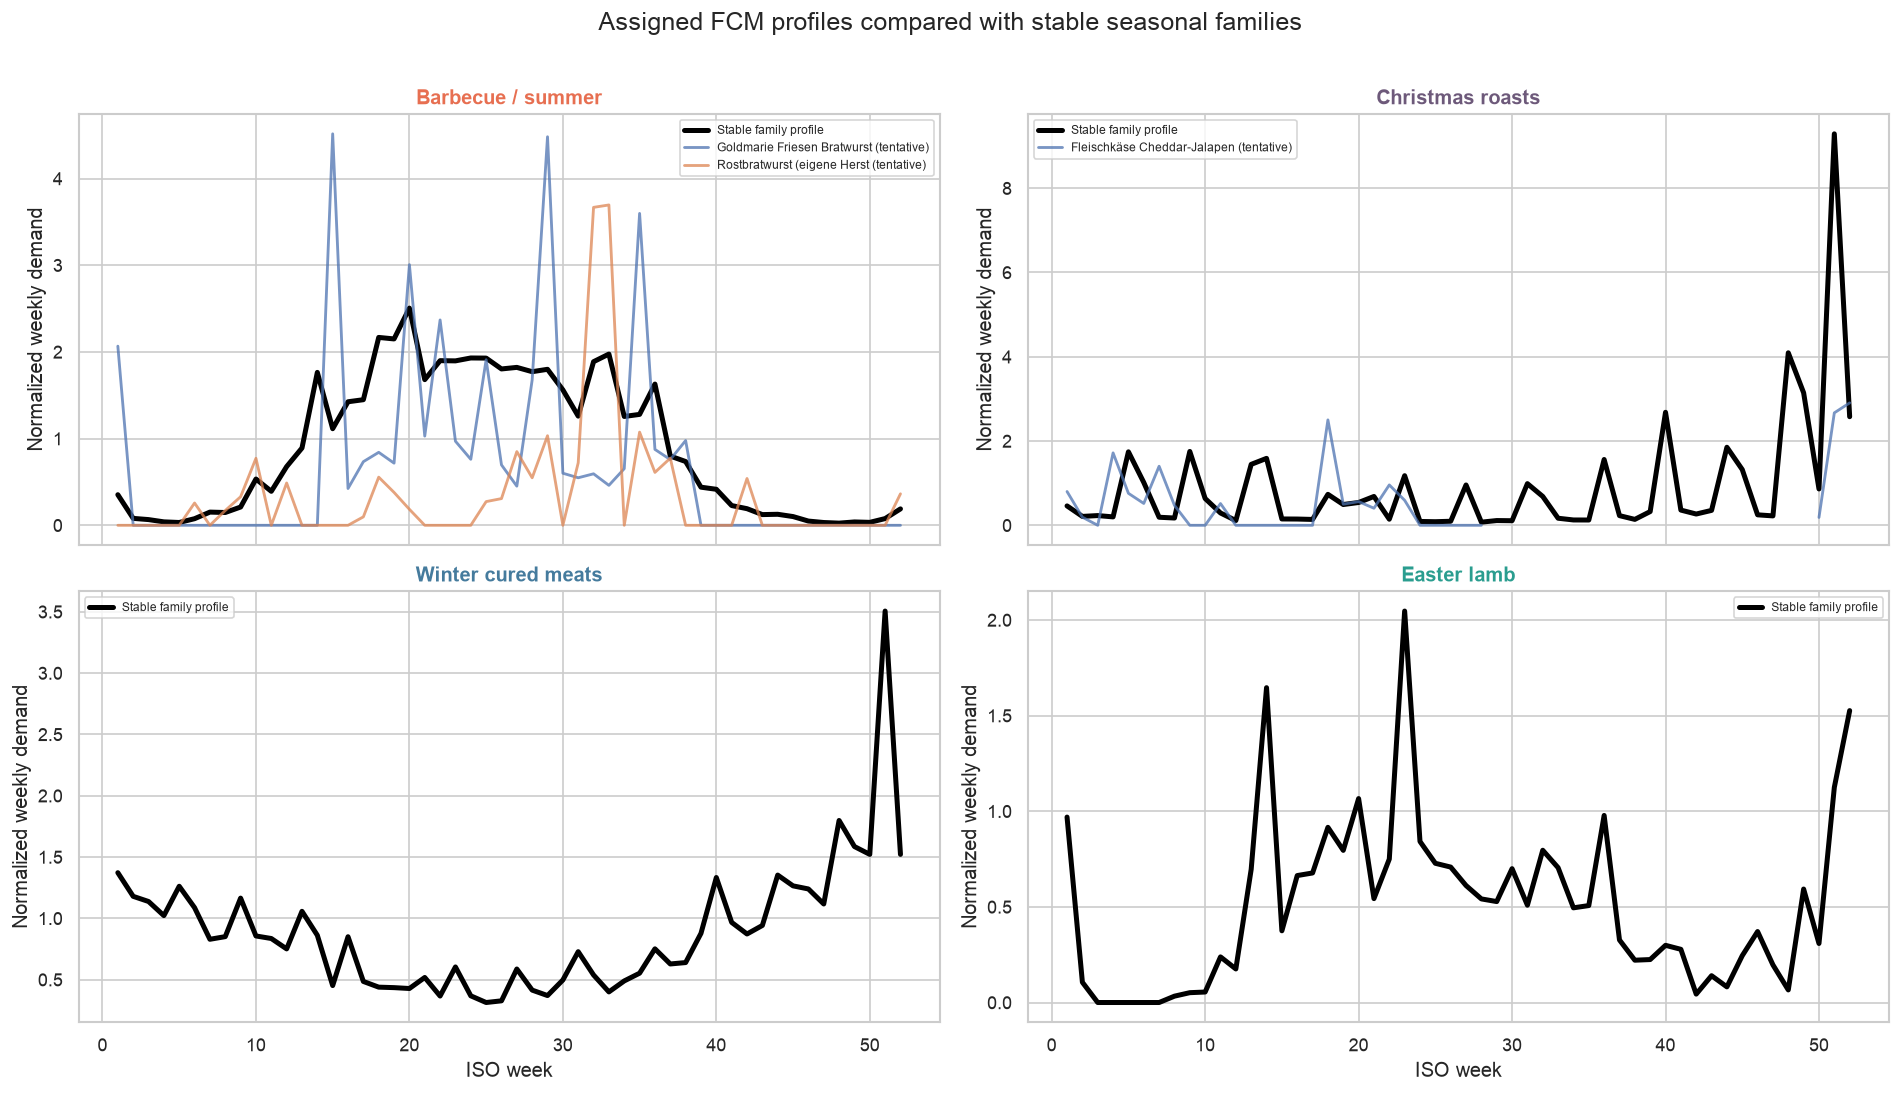

In [12]:
stable_group_prototypes = (
    group_profiles.groupby(["group", "sales_week"], as_index=False)
    .profile_value.median()
)

fcm_seasonal_profiles = fcm_profiles.copy()
fcm_seasonal_profiles["week_date"] = pd.to_datetime(fcm_seasonal_profiles.week_date)
fcm_seasonal_profiles["sales_week"] = (
    fcm_seasonal_profiles.week_date.dt.isocalendar().week.astype(int)
)
fcm_seasonal_profiles = (
    fcm_seasonal_profiles.groupby(
        ["article_id", "product_name", "sales_week"], as_index=False
    ).profile_value.mean()
)

eligible_fcm_assignment = recent_info.query(
    "source_class == 'FCM' and eligible_stores >= 10 and profile_weeks >= 26"
)
assignment_rows = []
for product in eligible_fcm_assignment.itertuples():
    product_curve = fcm_seasonal_profiles[
        fcm_seasonal_profiles.article_id == product.article_id
    ][["sales_week", "profile_value"]]
    correlations = []
    for group_name, group_curve in stable_group_prototypes.groupby("group"):
        comparison = product_curve.merge(
            group_curve[["sales_week", "profile_value"]],
            on="sales_week",
            suffixes=("_fcm", "_group"),
        )
        correlation = comparison.profile_value_fcm.corr(comparison.profile_value_group)
        correlations.append((group_name, correlation, len(comparison)))

    correlations.sort(key=lambda value: value[1], reverse=True)
    best_group, best_correlation, compared_weeks = correlations[0]
    second_group, second_correlation, _ = correlations[1]
    margin = best_correlation - second_correlation

    if best_correlation >= 0.60 and margin >= 0.10:
        confidence = "Strong"
        assigned_group = best_group
    elif best_correlation >= 0.30 and margin >= 0.05:
        confidence = "Tentative"
        assigned_group = best_group
    else:
        confidence = "Unassigned"
        assigned_group = "Unassigned"

    assignment_rows.append({
        "article_id": product.article_id,
        "FCM product": product.product_name,
        "assigned_group": assigned_group,
        "confidence": confidence,
        "best_matching_group": best_group,
        "best_correlation": best_correlation,
        "runner_up": second_group,
        "runner_up_correlation": second_correlation,
        "margin": margin,
        "compared_weeks": compared_weeks,
    })

fcm_assignments = pd.DataFrame(assignment_rows).sort_values("best_correlation", ascending=False)
display(fcm_assignments.reset_index(drop=True))

plot_assignments = fcm_assignments.sort_values("best_correlation")
bar_colors = [
    GROUP_COLORS.get(group, "#9E9E9E")
    for group in plot_assignments.assigned_group
]
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(
    plot_assignments["FCM product"],
    plot_assignments.best_correlation,
    color=bar_colors,
    alpha=0.85,
)
for y, row in enumerate(plot_assignments.itertuples()):
    ax.text(
        max(row.best_correlation, 0) + 0.015,
        y,
        f"{row.best_matching_group} · {row.confidence}",
        va="center",
        fontsize=8,
    )
ax.axvline(0.30, color="0.45", linestyle="--", linewidth=1, label="Tentative threshold")
ax.axvline(0.60, color="0.2", linestyle=":", linewidth=1.5, label="Strong threshold")
ax.set_xlim(min(-0.15, plot_assignments.best_correlation.min() - 0.05), 1.05)
ax.set_xlabel("Correlation with best stable seasonal family")
ax.set_title("Provisional seasonal-family assignment for FCM products")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True)
week_axis = pd.Index(range(1, 53), name="sales_week")
for ax, group_name in zip(axes.flat, PRODUCT_GROUPS):
    prototype = (
        stable_group_prototypes[stable_group_prototypes.group == group_name]
        .set_index("sales_week")
        .profile_value
        .reindex(week_axis)
    )
    ax.plot(week_axis, prototype, color="black", linewidth=3, label="Stable family profile")
    assigned_products = fcm_assignments[
        fcm_assignments.assigned_group == group_name
    ]
    for _, product in assigned_products.iterrows():
        curve = (
            fcm_seasonal_profiles[fcm_seasonal_profiles.article_id == product["article_id"]]
            .set_index("sales_week")
            .profile_value
            .reindex(week_axis)
        )
        ax.plot(
            week_axis,
            curve,
            linewidth=1.7,
            alpha=0.75,
            label=f"{product['FCM product'][:27]} ({product['confidence'].lower()})",
        )
    ax.set_title(group_name, color=GROUP_COLORS[group_name], fontweight="bold")
    ax.set_ylabel("Normalized weekly demand")
    ax.legend(fontsize=7)
for ax in axes[-1]:
    ax.set_xlabel("ISO week")
fig.suptitle("Assigned FCM profiles compared with stable seasonal families", fontsize=15, y=1.01)
fig.tight_layout()
plt.show()


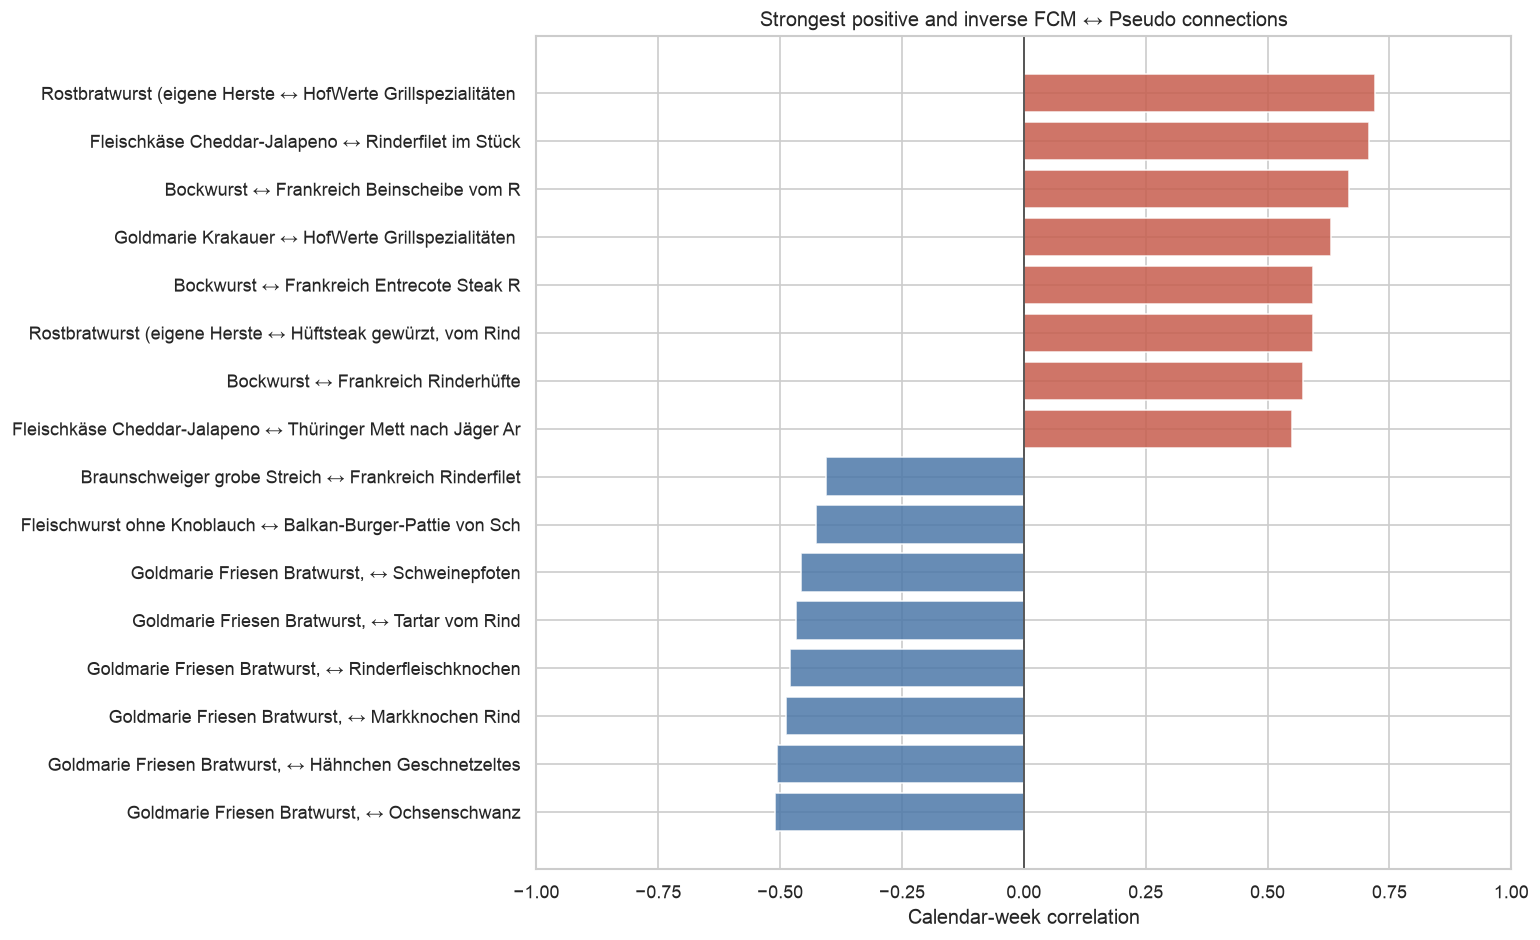

**Strongest positive FCM–Pseudo connections**

,FCM product,Pseudo product,correlation
0,Rostbratwurst (eigene Herstellung),HofWerte Grillspezialitäten vom Schwein,0.719675
1,Fleischkäse Cheddar-Jalapeno ofengebacken,Rinderfilet im Stück,0.707403
2,Bockwurst,Frankreich Beinscheibe vom Rind,0.667286
3,Goldmarie Krakauer,HofWerte Grillspezialitäten vom Schwein,0.629820
4,Bockwurst,Frankreich Entrecote Steak Rind,0.593876
5,Rostbratwurst (eigene Herstellung),"Hüftsteak gewürzt, vom Rind",0.592143
6,Bockwurst,Frankreich Rinderhüfte,0.571957
7,Fleischkäse Cheddar-Jalapeno ofengebacken,Thüringer Mett nach Jäger Art gewürzt vom Schwein,0.550669
8,Pizzafleischkäse ofengebacken,Krustenbraten vom Schwein,0.546458
9,Rostbratwurst (eigene Herstellung),Hähnchenbrustfilet gewürzt,0.543008


**Strongest inverse FCM–Pseudo connections**

,FCM product,Pseudo product,correlation
0,"Goldmarie Friesen Bratwurst, gebrüht",Ochsenschwanz,-0.511654
1,"Goldmarie Friesen Bratwurst, gebrüht",Hähnchen Geschnetzeltes,-0.506471
2,"Goldmarie Friesen Bratwurst, gebrüht",Markknochen Rind,-0.488778
3,"Goldmarie Friesen Bratwurst, gebrüht",Rinderfleischknochen,-0.479916
4,"Goldmarie Friesen Bratwurst, gebrüht",Tartar vom Rind,-0.468047
5,"Goldmarie Friesen Bratwurst, gebrüht",Schweinepfoten,-0.457146
6,Fleischwurst ohne Knoblauch,Balkan-Burger-Pattie von Schwein und Rind,-0.426710
7,Braunschweiger grobe Streichmettwurst,Frankreich Rinderfilet,-0.406720
8,Braunschweiger grobe Streichmettwurst,Frankreich Beinscheibe vom Rind,-0.381013
9,"Goldmarie Friesen Bratwurst, gebrüht",Hackfleisch vom Rind,-0.375848


In [13]:
recent_profiles = con.execute("""
    SELECT article_id, product_name, source_class, week_date, profile_value
    FROM recent_product_profile
""").fetchdf()
recent_profiles["key"] = (
    recent_profiles.source_class + ":" + recent_profiles.article_id.astype(str)
)
recent_wide = recent_profiles.pivot(index="week_date", columns="key", values="profile_value")
recent_corr = recent_wide.corr(min_periods=26)

eligible_keys = recent_info[
    (recent_info.eligible_stores >= 10) & (recent_info.profile_weeks >= 26)
].assign(key=lambda x: x.source_class + ":" + x.article_id.astype(str))

fcm_keys = [key for key in eligible_keys.query("source_class == 'FCM'").key if key in recent_corr.index]
pseudo_keys = [key for key in eligible_keys.query("source_class == 'Pseudo'").key if key in recent_corr.index]
fcm_pseudo_corr = recent_corr.loc[fcm_keys, pseudo_keys].dropna(how="all").dropna(axis=1, how="all")
fcm_pseudo_corr.index.name = "fcm_key"
fcm_pseudo_corr.columns.name = "pseudo_key"

key_name = recent_info.assign(
    key=lambda x: x.source_class + ":" + x.article_id.astype(str)
).set_index("key").product_name.to_dict()

pairs = fcm_pseudo_corr.stack().rename("correlation").reset_index()
pairs["FCM product"] = pairs["fcm_key"].map(key_name)
pairs["Pseudo product"] = pairs["pseudo_key"].map(key_name)
top_positive = pairs.nlargest(10, "correlation")[["FCM product", "Pseudo product", "correlation"]]
top_negative = pairs.nsmallest(10, "correlation")[["FCM product", "Pseudo product", "correlation"]]

connection_plot = pd.concat([top_positive.head(8), top_negative.head(8)]).copy()
connection_plot["pair"] = (
    connection_plot["FCM product"].str.slice(0, 28)
    + " ↔ "
    + connection_plot["Pseudo product"].str.slice(0, 28)
)
connection_plot = connection_plot.sort_values("correlation")
fig, ax = plt.subplots(figsize=(13, 8))
ax.barh(
    connection_plot.pair,
    connection_plot.correlation,
    color=np.where(connection_plot.correlation >= 0, "#C75D4D", "#4C78A8"),
    alpha=0.85,
)
ax.axvline(0, color="0.25", linewidth=1)
ax.set_xlim(-1, 1)
ax.set_xlabel("Calendar-week correlation")
ax.set_title("Strongest positive and inverse FCM ↔ Pseudo connections")
plt.tight_layout()
plt.show()

display(Markdown("**Strongest positive FCM–Pseudo connections**"))
display(top_positive.reset_index(drop=True))
display(Markdown("**Strongest inverse FCM–Pseudo connections**"))
display(top_negative.reset_index(drop=True))


## 8. Products without clear connections

A product is treated as relatively disconnected when both are low:

- its median cross-store agreement; and
- its strongest absolute correlation with any other eligible 52-week product profile.

The ranking below is relative, not a claim that demand is random. Local assortment changes, promotions, sparse demand, or movable events can all reduce these correlations.

,article_id,product_name,source_class,eligible_stores,median_store_correlation,max_abs_product_correlation,median_year_correlation,seasonal_cv
0,221686,Reinert Chambelle Edelsalami m.Camenbert,Other,29,0.157933,0.479277,-0.005032,0.118805
1,605950,Goldmarie grober Hackbraten umgerötet,Other,11,0.181005,0.487000,-0.016918,0.731024
2,111586,Bedf. Truthahnsauerfleisch m. Silberzwiebeln,Other,43,0.201312,0.438791,0.020735,0.095063
3,903213,Sostmann Cervelatwurst,Other,14,0.205402,0.441787,0.033490,0.597126
4,984227,"orig. ital. Landschinken ""Prosciutto Crudo""",Other,16,0.245291,0.420780,0.065006,0.209985
5,905944,Kaisersülze in Scheiben,Other,18,0.227446,0.451512,0.028092,0.202241
6,290073,Spilker Corned Beef,Other,63,0.154850,0.542218,0.093047,1.073136
7,990503,GV Schweine Lachs,Pseudo,11,0.302322,0.355939,-0.120131,0.940674
8,878702,R&S Imperial 100% Hähnchensalami-Pralinen,Other,16,0.226211,0.488608,-0.161745,0.241266
9,956914,SP Orig. Pfälzer Leberwurst im Kunstdarm,Other,67,0.182500,0.557110,0.109717,0.108743


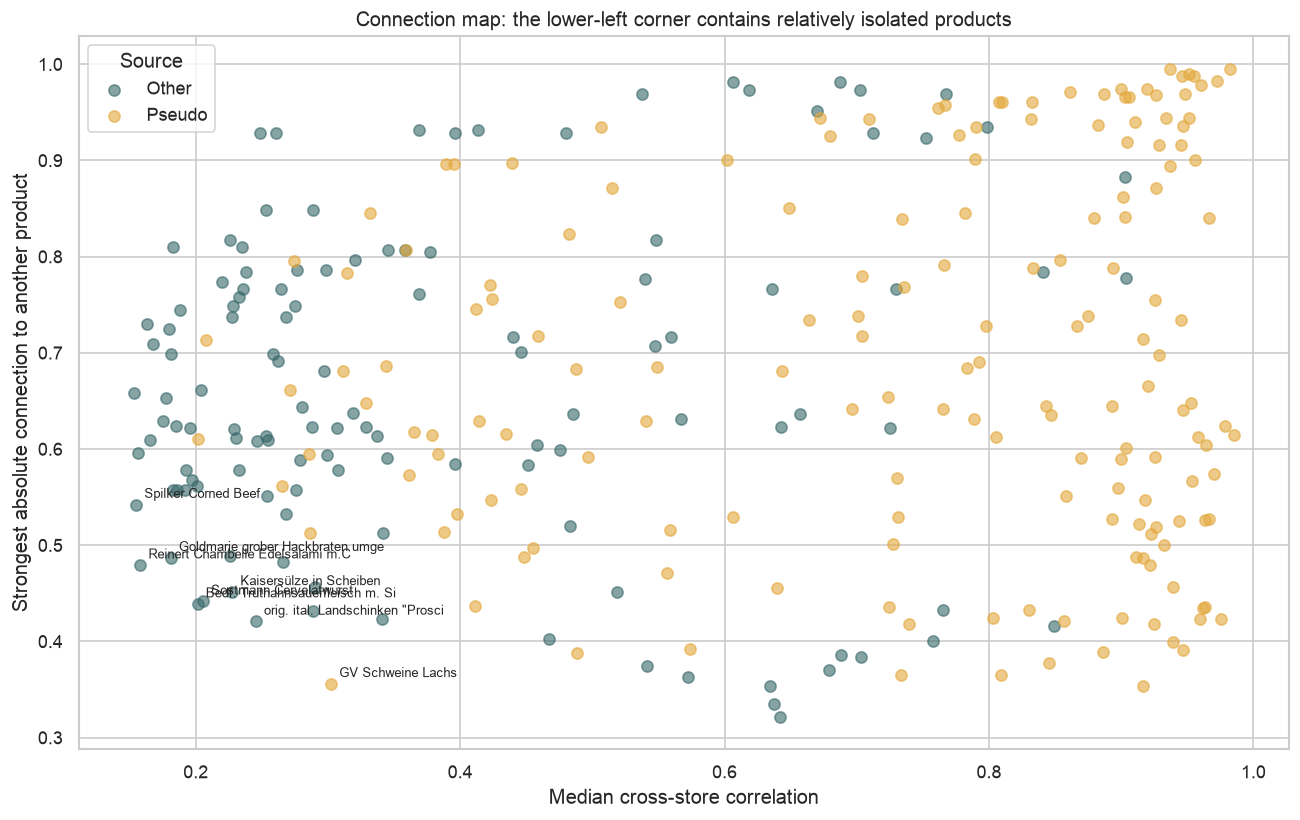

In [14]:
all_profiles = con.execute("""
    SELECT article_id, sales_week, profile_value
    FROM product_profile
""").fetchdf()

eligible_ids = analysis_metrics.article_id.tolist()
profile_wide = (
    all_profiles[all_profiles.article_id.isin(eligible_ids)]
    .pivot(index="sales_week", columns="article_id", values="profile_value")
)
profile_correlations = profile_wide.corr(min_periods=40)
np.fill_diagonal(profile_correlations.values, np.nan)
max_abs_product_corr = profile_correlations.abs().max(axis=1).rename("max_abs_product_correlation")

connectivity = analysis_metrics.merge(
    max_abs_product_corr,
    left_on="article_id",
    right_index=True,
    how="left",
)
connectivity["store_connection_rank"] = connectivity.median_store_correlation.rank(pct=True)
connectivity["product_connection_rank"] = connectivity.max_abs_product_correlation.rank(pct=True)
connectivity["isolation_score"] = (
    connectivity.store_connection_rank + connectivity.product_connection_rank
) / 2

isolated = connectivity.nsmallest(10, "isolation_score")
display(
    isolated[[
        "article_id", "product_name", "source_class", "eligible_stores",
        "median_store_correlation", "max_abs_product_correlation",
        "median_year_correlation", "seasonal_cv",
    ]].reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(11, 7))
for source_class, group in connectivity.groupby("source_class"):
    ax.scatter(
        group.median_store_correlation,
        group.max_abs_product_correlation,
        color=SOURCE_COLORS[source_class],
        alpha=0.6,
        s=45,
        label=source_class,
    )
for row in isolated.head(8).itertuples():
    ax.annotate(
        row.product_name[:32],
        (row.median_store_correlation, row.max_abs_product_correlation),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8,
    )
ax.set_xlabel("Median cross-store correlation")
ax.set_ylabel("Strongest absolute connection to another product")
ax.set_title("Connection map: the lower-left corner contains relatively isolated products")
ax.legend(title="Source")
plt.tight_layout()
plt.show()


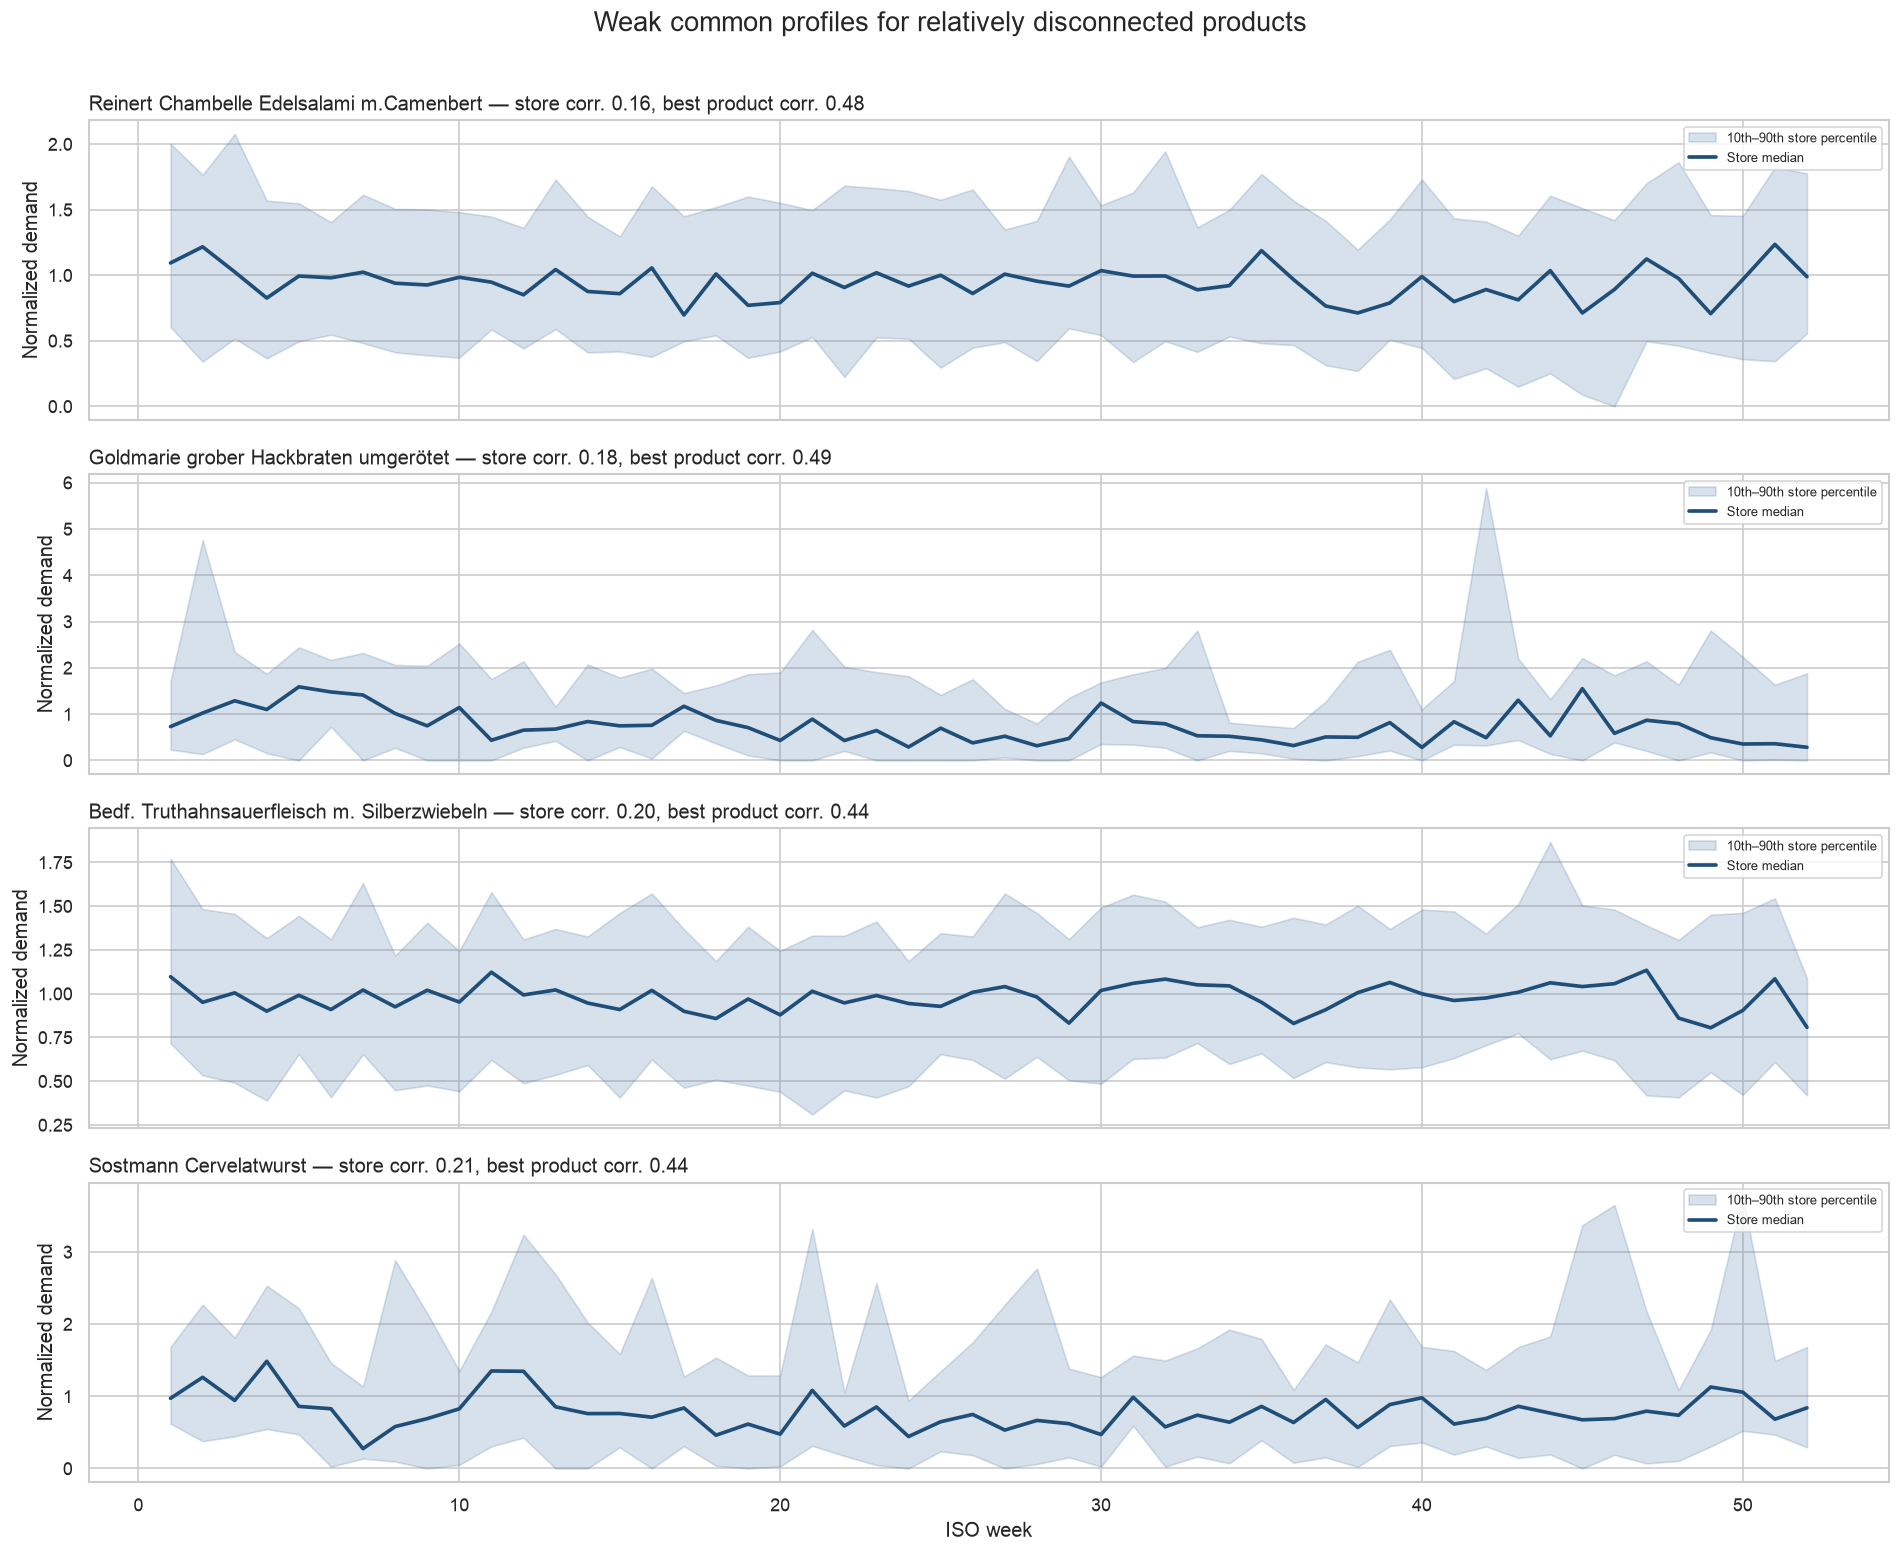

In [15]:
isolated_ids = isolated.head(4).article_id.tolist()

fig, axes = plt.subplots(len(isolated_ids), 1, figsize=(16, 3.2 * len(isolated_ids)), sharex=True)
if len(isolated_ids) == 1:
    axes = [axes]

for ax, article_id in zip(axes, isolated_ids):
    store_profiles = con.execute(f"""
        SELECT
            store_id,
            sales_week,
            avg(normalized_demand) AS normalized_demand
        FROM normalized_store_year_week
        WHERE article_id = {int(article_id)}
        GROUP BY store_id, sales_week
    """).fetchdf()
    matrix = store_profiles.pivot(
        index="store_id", columns="sales_week", values="normalized_demand"
    )
    median_profile = matrix.median(axis=0)
    lower_profile = matrix.quantile(0.10, axis=0)
    upper_profile = matrix.quantile(0.90, axis=0)
    ax.fill_between(
        matrix.columns,
        lower_profile,
        upper_profile,
        color="#4C78A8",
        alpha=0.22,
        label="10th–90th store percentile",
    )
    ax.plot(matrix.columns, median_profile, color="#1F4E79", linewidth=2.2, label="Store median")
    row = isolated[isolated.article_id == article_id].iloc[0]
    ax.set_title(
        f"{row.product_name} — store corr. {row.median_store_correlation:.2f}, "
        f"best product corr. {row.max_abs_product_correlation:.2f}",
        loc="left",
    )
    ax.set_ylabel("Normalized demand")
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("ISO week")
fig.suptitle("Weak common profiles for relatively disconnected products", fontsize=16, y=1.01)
fig.tight_layout()
plt.show()


## Interpretation notes

- High correlation is evidence of synchronized timing, not causality. Promotions, assortment rollouts, holidays, and weather can all produce it.
- FCM should not be judged by the three-year repeatability standard: its history is too short. The FCM–Pseudo matrix is exploratory until another full annual cycle is available.
- Fixed ISO-week profiles miss movable holidays. The Easter-aligned lamb plot demonstrates why event-relative analysis matters.
- “Disconnected” means weak relative connections under these definitions; it does not mean that a product is intrinsically unpredictable.